# Objectifs

### 1 - Comparer la distribution des nutriments selon l'aliment
Par exemple : Pouvoir identifier si les algues sont plus en moins riches en protéine que la viande cuite

Autre exemple : Pouvoir identifier quels aliments ont des valeurs nutritionnels proches des algues

### 2 - Define steps to take

1. Clean and prepare data. 
    a) only include numerical values
    b) handle NAN values
    c) normalize or scale if necessary

2. Choose clustering algorithm

3. Implement clustering
    a) Finishing preparing data set
    b) Train_test_split
    c) Train model and transform data
    d) Visualize clustering result


# Here we go

## Clean dataset

### import libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

load_dotenv(override=True) 



from lxml import etree # for importing other dataset that has 'alim_nom_fr' + 'ALIM_INDEX_FR' columns



### import dataset + check import

In [6]:
CIQUAL_DATA = os.getenv("CIQUAL_DATA")


In [7]:
CIQUAL_DATA = os.getenv("CIQUAL_DATA")


df_ciqual = pd.read_excel(CIQUAL_DATA)

/opt/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [8]:
df_ciqual.head()

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,NaN,...,NaN,NaN,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,-,...,-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,-,...,"9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,-,...,-,-,"6,67","0,056","0,21","1,84","0,88","0,088","19,6","0,018"
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,-,...,-,-,10,"0,077","0,06","0,89","0,53","0,14",7,0


In [9]:
df_ciqual_seaweed = df_ciqual[df_ciqual['alim_ssgrp_nom_eng'].str.contains('seaweed', case=False, na=False)]

print(f"Number of seaweeds in database: {df_ciqual_seaweed.shape[0]}")
df_ciqual_seaweed

Number of seaweeds in database: 17


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,alim_nom_sci,"Energy, Regulation EU No 1169/2011 (kJ/100g)",...,Vitamin K1 (µg/100g),Vitamin K2 (µg/100g),Vitamin C (mg/100g),Vitamin B1 or Thiamin (mg/100g),Vitamin B2 or Riboflavin (mg/100g),Vitamin B3 or Niacin (mg/100g),Vitamin B5 or Pantothenic acid (mg/100g),Vitamin B6 (mg/100g),Vitamin B9 or Folate (µg/100g),Vitamin B12 (µg/100g)
3098,10,1007,0,miscellaneous,seaweed,-,11084,"Seaweed, agar, raw",NaN,-,...,"2,3",-,0,"0,005","0,022","0,055","0,3","0,032",85,0
3099,10,1007,0,miscellaneous,seaweed,-,11085,"Seaweed, agar, dried",NaN,-,...,"24,4",-,0,"0,01","0,22","0,2","3,02","0,3",580,0
3100,10,1007,0,miscellaneous,seaweed,-,11086,"Spirulina, (spirulina sp.), dried",NaN,-,...,"25,5",-,"10,1","2,38","3,67","12,8","3,48","0,36",94,0
3101,10,1007,0,miscellaneous,seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated",NaN,760,...,732,-,28,"0,34","0,78","6,39","0,16","0,18",237,"0,23"
3102,10,1007,0,miscellaneous,seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)",NaN,856,...,-,-,"54,6","0,13","0,25","8,59","0,15",-,53,"9,55"
3103,10,1007,0,miscellaneous,seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehy...",NaN,849,...,-,-,"11,4","0,44","0,34",-,-,-,-,-
3104,10,1007,0,miscellaneous,seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated",NaN,1060,...,-,-,"57,3","0,58","1,91","5,82","0,25","0,53","21,7","38,8"
3105,10,1007,0,miscellaneous,seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated",NaN,949,...,420,-,"83,6","0,37","0,48","4,31","0,4","0,013",92,"9,81"
3106,10,1007,0,miscellaneous,seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), d...",NaN,931,...,-,-,"15,1","0,21","0,48","1,5",-,"0,081",127,"1,52"
3107,10,1007,0,miscellaneous,seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated",NaN,905,...,-,-,"0,024",-,-,"3,03",-,-,-,-


### Shape

In [10]:
# size of dataset
df_ciqual.shape
# 3186 rows (foods), 76 columns (features)

(3186, 76)

## Graphs to show nutritional values for seaweeds

In [11]:
df_ciqual_seaweed.columns

Index(['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng', 'alim_nom_sci',
       'Energy, Regulation EU No 1169/2011 (kJ/100g)',
       'Energy, Regulation EU No 1169/2011 (kcal/100g)',
       'Energy, N x Jones' factor, with fibres (kJ/100g)',
       'Energy, N x Jones' factor, with fibres (kcal/100g)', 'Water (g/100g)',
       'Protein (g/100g)', 'Protein, crude, N x 6.25 (g/100g)',
       'Carbohydrate (g/100g)', 'Fat (g/100g)', 'Sugars (g/100g)',
       'fructose (g/100g)', 'galactose (g/100g)', 'glucose (g/100g)',
       'lactose (g/100g)', 'maltose (g/100g)', 'sucrose (g/100g)',
       'Starch (g/100g)', 'Fibres (g/100g)', 'Polyols (g/100g)',
       'Ash (g/100g)', 'Alcohol (g/100g)', 'Organic acids (g/100g)',
       'FA saturated (g/100g)', 'FA mono (g/100g)', 'FA poly (g/100g)',
       'FA 4:0 (g/100g)', 'FA 6:0 (g/100g)', 'FA 8:0 (g/100g)',
       'FA 10:0 (g/100g

### features (columns) & NANs

In [12]:
df_ciqual.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 76 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   alim_grp_code                                       3186 non-null   int64 
 1   alim_ssgrp_code                                     3186 non-null   int64 
 2   alim_ssssgrp_code                                   3186 non-null   int64 
 3   alim_grp_nom_eng                                    3141 non-null   object
 4   alim_ssgrp_nom_eng                                  3141 non-null   object
 5   alim_ssssgrp_nom_eng                                3141 non-null   object
 6   alim_code                                           3186 non-null   int64 
 7   alim_nom_eng                                        3186 non-null   object
 8   alim_nom_sci                                        270 non-null    object
 9   Energy, 

### description of features

### 

#### Identification & Foods (9)
- 'alim_grp_code': Code identifying the main food group.
- 'alim_ssgrp_code': Code for the sub-group within the food group.
- 'alim_ssssgrp_code': Code for the sub-sub-group within the food hierarchy.
- 'alim_grp_nom_eng': Name of the main food group (in English).
- 'alim_ssgrp_nom_eng': Name of the food sub-group (in English).
- 'alim_ssssgrp_nom_eng': Name of the food sub-sub-group (in English).
- 'alim_code': Unique identifier for each food item.
- 'alim_nom_eng': English name of the food item.
- 'alim_nom_sci': Scientific or Latin name (if applicable).



#### Energy (4)

- 'Energy, Regulation EU No 1169/2011 (kJ/100g)': Energy per 100g based on EU Regulation (in kilojoules).
- 'Energy, Regulation EU No 1169/2011 (kcal/100g)': Energy per 100g based on EU Regulation (in kilocalories).
- 'Energy, N x Jones\' factor, with fibres (kJ/100g)': Energy with fiber included, using the nitrogen factor (in kJ).
- 'Energy, N x Jones\' factor, with fibres (kcal/100g)': Same as above, expressed in kcal.


#### Basic Nutrients (5)

- 'Water (g/100g)': Water content per 100g.
- 'Protein (g/100g)': Total protein content per 100g.
- 'Protein, crude, N x 6.25 (g/100g)': Crude protein estimate using nitrogen conversion factor 6.25.
- 'Carbohydrate (g/100g)': Total available carbohydrates per 100g.
- 'Fat (g/100g)': Total fat content per 100g.



#### Sugars & Carbs (10)

- 'Sugars (g/100g)': Total sugars per 100g.
- 'fructose (g/100g)': Fructose content per 100g.
- 'galactose (g/100g)': Galactose content per 100g.
- 'glucose (g/100g)': Glucose content per 100g.
- 'lactose (g/100g)': Lactose content per 100g.
- 'maltose (g/100g)': Maltose content per 100g.
- 'sucrose (g/100g)': Sucrose content per 100g.
- 'Starch (g/100g)': Starch content per 100g.
- 'Fibres (g/100g)': Dietary fiber content per 100g.
- 'Polyols (g/100g)': Sugar alcohols (polyols) content per 100g.


#### Other Organic Compounds (3)

- 'Ash (g/100g)': Total mineral residue (ash) after burning per 100g.
- 'Alcohol (g/100g)': Ethanol content per 100g.
- 'Organic acids (g/100g)': Organic acids (e.g. citric, lactic) per 100g.


#### Fatty Acids (17)

- 'FA saturated (g/100g)': Total saturated fatty acids per 100g.
- 'FA mono (g/100g)': Total monounsaturated fatty acids per 100g.
- 'FA poly (g/100g)': Total polyunsaturated fatty acids per 100g.
- 'FA 4:0 (g/100g)': Butyric acid (short-chain saturated fatty acid).
- 'FA 6:0 (g/100g)': Caproic acid (saturated).
- 'FA 8:0 (g/100g)': Caprylic acid (saturated).
- 'FA 10:0 (g/100g)': Capric acid (saturated).
- 'FA 12:0 (g/100g)': Lauric acid (saturated).
- 'FA 14:0 (g/100g)': Myristic acid (saturated).
- 'FA 16:0 (g/100g)': Palmitic acid (saturated).
- 'FA 18:0 (g/100g)': Stearic acid (saturated).
- 'FA 18:1 n-9 cis (g/100g)': Oleic acid (main monounsaturated fat).
- 'FA 18:2 9c,12c (n-6) (g/100g)': Linoleic acid (omega-6).
- 'FA 18:3 c9,c12,c15 (n-3) (g/100g)': Alpha-linolenic acid (omega-3).
- 'FA 20:4 5c,8c,11c,14c (n-6) (g/100g)': Arachidonic acid (omega-6).
- 'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)': EPA, an omega-3 fatty acid.
- 'FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)': DHA, an omega-3 fatty acid.


#### Cholesterol & Salt (2)

- 'Cholesterol (mg/100g)': Cholesterol content per 100g.
- 'Salt (g/100g)': Salt content (as NaCl) per 100g.


#### Minerals (12)

- 'Calcium (mg/100g)': Calcium content per 100g.
- 'Chloride (mg/100g)': Chloride content per 100g.
- 'Copper (mg/100g)': Copper content per 100g.
- 'Iron (mg/100g)': Iron content per 100g.
- 'Iodine (µg/100g)': Iodine content per 100g.
- 'Magnesium (mg/100g)': Magnesium content per 100g.
- 'Manganese (mg/100g)': Manganese content per 100g.
- 'Phosphorus (mg/100g)': Phosphorus content per 100g.
- 'Potassium (mg/100g)': Potassium content per 100g.
- 'Selenium (µg/100g)': Selenium content per 100g.
- 'Sodium (mg/100g)': Sodium content per 100g.
- 'Zinc (mg/100g)': Zinc content per 100g.


#### Vitamins (14)

- 'Retinol (µg/100g)': Preformed vitamin A (retinol) per 100g.
- 'Beta-carotene (µg/100g)': Beta-carotene content (vitamin A precursor).
- 'Vitamin D (µg/100g)': Vitamin D content per 100g.
- 'Vitamin E (mg/100g)': Vitamin E (alpha-tocopherol) per 100g.
- 'Vitamin K1 (µg/100g)': Phylloquinone (vitamin K1) per 100g.
- 'Vitamin K2 (µg/100g)': Menaquinones (vitamin K2) per 100g.
- 'Vitamin C (mg/100g)': Vitamin C (ascorbic acid) per 100g.
- 'Vitamin B1 or Thiamin (mg/100g)': Vitamin B1 (thiamin) content per 100g.
- 'Vitamin B2 or Riboflavin (mg/100g)': Vitamin B2 (riboflavin) per 100g.
- 'Vitamin B3 or Niacin (mg/100g)': Vitamin B3 (niacin) per 100g.
- 'Vitamin B5 or Pantothenic acid (mg/100g)': Vitamin B5 per 100g.
- 'Vitamin B6 (mg/100g)': Vitamin B6 content per 100g.
- 'Vitamin B9 or Folate (µg/100g)': Folate (vitamin B9) per 100g.
- 'Vitamin B12 (µg/100g)': Vitamin B12 (cobalamin) per 100g.

In [13]:
# ID, food columns

foods_list = [
    "alim_grp_code",
    "alim_ssgrp_code",
    "alim_ssssgrp_code",
    "alim_grp_nom_eng",
    "alim_ssgrp_nom_eng",
    "alim_ssssgrp_nom_eng",
    "alim_code",
    "alim_nom_eng",
]


### 20 features to keep for nutritional value comparison

### options 1 - international audience


#### Macronutrients
1. Energy (kcal/100g) – How many calories are in the food.
2. Protein (g/100g) – Supports muscle, satiety; people often track this.
3. Fat (g/100g) – Total fat content, key for energy and flavor.
4. Saturated fat (g/100g) – Often associated with cardiovascular risk.
5. Carbohydrates (g/100g) – Energy source, varies widely across food types.
6. Sugars (g/100g) – Simple sugars, linked to processed food perception.
7. Fibres (g/100g) – Important for digestion and gut health.


#### Minerals
8. Sodium (mg/100g) – Linked to salt intake and blood pressure.
9. Iron (mg/100g) – Known for its role in energy and preventing anemia.
10. Calcium (mg/100g) – Bone health; especially known from dairy contexts.
11. Magnesium (mg/100g) – Important for muscles and nerves.
12. Zinc (mg/100g) – Immunity and skin health.
13. Iodine (µg/100g) – Seaweed is often rich in this; important for thyroid.
14. Potassium (mg/100g) – Balances sodium, heart and muscle function.


#### Vitamins
15. Vitamin C (mg/100g) – Immunity, antioxidant, familiar from citrus.
16. Vitamin B12 (µg/100g) – Important for vegans/vegetarians.
17. Vitamin A (as Retinol or Beta-carotene) – Eyesight, immunity.
18. Vitamin D (µg/100g) – Bone health, mood; often deficient in modern diets.
19. Vitamin E (mg/100g) – Antioxidant, skin health.


In [14]:
# features list for an internaitonal audience
nutrients_list_intl = [
    "Energy, Regulation EU No 1169/2011 (kcal/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Carbohydrate (g/100g)",
    "Sugars (g/100g)",
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Salt (g/100g)",
    "Iron (mg/100g)",
    "Calcium (mg/100g)",
    "Magnesium (mg/100g)",
    "Vitamin C (mg/100g)",
    "Vitamin B12 (µg/100g)",
    "Vitamin B9 or Folate (µg/100g)",
    "Vitamin D (µg/100g)",
    "Vitamin E (mg/100g)",
    "Zinc (mg/100g)",
    "Iodine (µg/100g)",
    "Cholesterol (mg/100g)",
    "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)",
    "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",    
    #"Omega-3 EPA & DHA" --> must be created by adding "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)" + "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
]


# filter dataset on this column list

df_nutri_intl = df_ciqual[foods_list + nutrients_list_intl] 

df_nutri_intl.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   alim_grp_code                                     3186 non-null   int64 
 1   alim_ssgrp_code                                   3186 non-null   int64 
 2   alim_ssssgrp_code                                 3186 non-null   int64 
 3   alim_grp_nom_eng                                  3141 non-null   object
 4   alim_ssgrp_nom_eng                                3141 non-null   object
 5   alim_ssssgrp_nom_eng                              3141 non-null   object
 6   alim_code                                         3186 non-null   int64 
 7   alim_nom_eng                                      3186 non-null   object
 8   Energy, Regulation EU No 1169/2011 (kcal/100g)    3169 non-null   object
 9   Fat (g/100g)                  

### option 2 - French national audience 

1. Valeur énergétique (kJ)
2. Énergie (kcal)
3. Matières grasses
4. dont acides gras saturés
5. Glucides – Carbohydrates 
6. dont sucres – of which sugars
7. Fibres alimentaires 
8. Protéines – Protein
9. Sel   

<br />
   
10. Fer (Iron) – Common deficiency.
11. Calcium – For bone health.
12. Vitamine C – Immune system.
13. Vitamine D – Especially in winter.
14. Oméga-3 (EPA + DHA) – Heart and brain health.


In [15]:
# features list for French audience
nutrients_list_fr = [
    "Energy, Regulation EU No 1169/2011 (kJ/100g)",
    "Energy, Regulation EU No 1169/2011 (kcal/100g)",
    "Fat (g/100g)",
    "FA saturated (g/100g)",
    "Carbohydrate (g/100g)",
    "Sugars (g/100g)",
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Salt (g/100g)",
    "Iron (mg/100g)",
    "Calcium (mg/100g)",
    "Vitamin C (mg/100g)",
    "Vitamin D (µg/100g)",
    "Iodine (µg/100g)",
    "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)",
    "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",    
    #"Omega-3 EPA & DHA" --> must be created by adding "FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)" + "FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
]


df_nutrients_fr = df_ciqual[foods_list + nutrients_list_fr]

df_nutrients_fr.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3186 entries, 0 to 3185
Data columns (total 24 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   alim_grp_code                                     3186 non-null   int64 
 1   alim_ssgrp_code                                   3186 non-null   int64 
 2   alim_ssssgrp_code                                 3186 non-null   int64 
 3   alim_grp_nom_eng                                  3141 non-null   object
 4   alim_ssgrp_nom_eng                                3141 non-null   object
 5   alim_ssssgrp_nom_eng                              3141 non-null   object
 6   alim_code                                         3186 non-null   int64 
 7   alim_nom_eng                                      3186 non-null   object
 8   Energy, Regulation EU No 1169/2011 (kJ/100g)      3169 non-null   object
 9   Energy, Regulation EU No 1169/

### Handling NAN values


- Determine if NAN values are in rows in food subgroups related to this analysis.


In [16]:
# observe total number of NAN values per column 
df_nutri_intl.isnull().sum()

# IMPORTANT NOTE: further analysis of values (see below) reveals that there are lot more NaN values than this initial search displays
# Notably, there is often the string "-", which is not detected as a NaN, when in reality it is for the case of this analysis

alim_grp_code                                        0
alim_ssgrp_code                                      0
alim_ssssgrp_code                                    0
alim_grp_nom_eng                                    45
alim_ssgrp_nom_eng                                  45
alim_ssssgrp_nom_eng                                45
alim_code                                            0
alim_nom_eng                                         0
Energy, Regulation EU No 1169/2011 (kcal/100g)      17
Fat (g/100g)                                         1
FA saturated (g/100g)                                5
Carbohydrate (g/100g)                                1
Sugars (g/100g)                                      9
Fibres (g/100g)                                      1
Protein (g/100g)                                     1
Salt (g/100g)                                        6
Iron (mg/100g)                                       8
Calcium (mg/100g)                                   10
Magnesium 

In [17]:
# observing foods concerned by NANs in energy column
df_nutri_intl[df_nutri_intl['Energy, Regulation EU No 1169/2011 (kcal/100g)'].isnull()]

# the only food that may be interesting to not remove is "Olives, black (average food)", as it could be something people might replace with seaweed 
# The rest of these foods wouldn't make sense to compare with seaweed 
# (e.g. Desert (average), Apricots canned in syrop (sugar content unknown), Fruit cocktail or salad, canned in syrup (suga...), 
# non-alcoholic beverages (average), flavoured milk with sugar - partially skimmed, wine (average), cider (average), 
# cake (average), pastry (average), ice cream or sorbet or ice pop, flavoured (average), etc.)

# it makes sense to remove this rows as well as rows for foods like Wheat bran, which has NAN values across the board


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
0,0,0,0,NaN,NaN,NaN,24999,Desert (average),NaN,"12,9",...,"1,37","0,21","30,8","0,27","1,97","0,5",11,"56,7","0,0041","0,0051"
712,2,203,20301,"fruits, vegetables, legumes and nuts",legumes,"legumes, cooked",20700,"Legume, cooked (average)",NaN,"0,62",...,"1,05",0,131,"0,038","0,099","0,9","5,47",0,"0,0018","0,0018"
827,2,204,20403,"fruits, vegetables, legumes and nuts",fruits,canned fruits,13704,"Apricot, canned in syrup (sugar content unknow...",NaN,"0,25",...,"0,25",NaN,"9,3",NaN,NaN,"0,06",10,NaN,NaN,NaN
828,2,204,20403,"fruits, vegetables, legumes and nuts",fruits,canned fruits,13705,"Fruit cocktail or salad, canned in syrup (suga...",NaN,"0,25",...,"2,91",NaN,"10,8",NaN,NaN,"0,025",NaN,NaN,NaN,NaN
2397,6,602,60203,beverages,non-alcoholic beverages,soft drinks,18029,Non-alcoholic beverage (average),NaN,"0,042",...,"1,78","0,0054","1,3","0,0099","0,0092","0,02","1,16","0,06",NaN,NaN
2428,6,602,60204,beverages,non-alcoholic beverages,dairy beverages,19120,"Flavoured milk, with sugar, partially skimmed,...",NaN,"1,08",...,NaN,"0,34",NaN,"0,77",NaN,NaN,NaN,NaN,NaN,NaN
2481,6,603,60301,beverages,alcoholic beverages,wines,5210,Wine (average),NaN,0,...,"0,034",0,"0,79",0,0,"0,088","2,07",0,0,0
2488,6,603,60302,beverages,alcoholic beverages,beers and ciders,5003,Cider (average),NaN,"0,083",...,"10,3",NaN,NaN,NaN,NaN,"0,022","3,27",NaN,NaN,NaN
2747,7,709,0,sugar and confectionery,cakes and pastry,-,23000,Cake (average),NaN,"17,8",...,"0,41","0,21",35,"0,41","3,23","0,52","11,5","85,8","0,0047","0,0057"
2814,7,709,0,sugar and confectionery,cakes and pastry,-,23900,Pastry (average),NaN,"17,2",...,"3,46","0,25","43,1","0,28","2,61","0,51",12,"72,7","0,0038","0,0049"


In [18]:
# removing specific rows (explanation above)

df_nutri_intl = df_nutri_intl[
    ~(
        df_nutri_intl['Energy, Regulation EU No 1169/2011 (kcal/100g)'].isna() & 
        (df_nutri_intl['alim_code'] != 13186)
      )
      ]

#checking that all rows, except olives, black (average food) , were removed
df_nutri_intl['Energy, Regulation EU No 1169/2011 (kcal/100g)'].isnull().sum()

1

In [19]:
# list to use later to display only all rows with missing NAN values
print(df_nutri_intl.isnull().columns)

# assign list to variable
columns_with_nans = ['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng',
       'Energy, Regulation EU No 1169/2011 (kcal/100g)', 'Fat (g/100g)',
       'FA saturated (g/100g)', 'Carbohydrate (g/100g)', 'Sugars (g/100g)',
       'Fibres (g/100g)', 'Protein (g/100g)', 'Salt (g/100g)',
       'Iron (mg/100g)', 'Calcium (mg/100g)', 'Magnesium (mg/100g)',
       'Vitamin C (mg/100g)', 'Vitamin B12 (µg/100g)',
       'Vitamin B9 or Folate (µg/100g)', 'Vitamin D (µg/100g)',
       'Vitamin E (mg/100g)', 'Zinc (mg/100g)', 'Iodine (µg/100g)',
       'Cholesterol (mg/100g)', 'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)',
       'FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)']

Index(['alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
       'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
       'alim_code', 'alim_nom_eng',
       'Energy, Regulation EU No 1169/2011 (kcal/100g)', 'Fat (g/100g)',
       'FA saturated (g/100g)', 'Carbohydrate (g/100g)', 'Sugars (g/100g)',
       'Fibres (g/100g)', 'Protein (g/100g)', 'Salt (g/100g)',
       'Iron (mg/100g)', 'Calcium (mg/100g)', 'Magnesium (mg/100g)',
       'Vitamin C (mg/100g)', 'Vitamin B12 (µg/100g)',
       'Vitamin B9 or Folate (µg/100g)', 'Vitamin D (µg/100g)',
       'Vitamin E (mg/100g)', 'Zinc (mg/100g)', 'Iodine (µg/100g)',
       'Cholesterol (mg/100g)', 'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)',
       'FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)'],
      dtype='object')


In [20]:
df_nutri_intl[df_nutri_intl['Energy, Regulation EU No 1169/2011 (kcal/100g)'].isnull()]


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
3026,10,1002,0,miscellaneous,condiments,-,13186,"Olives, black (average food)",NaN,"19,5",...,"0,3","0,004","2,98",0,"5,6","0,21",10,"0,35","0,0041","0,0041"


In [21]:
# display max rows
#pd.set_option('display.max_rows', None)

# display max columns
#pd.set_option('display.max_columns', None) 


# observing foods with NAN values an any column
df_nutri_intl[df_nutri_intl[columns_with_nans].isnull().any(axis=1)]

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
66,1,102,0,starters and dishes,soups,-,25969,Soup (average),"37,4","1,37",...,"5,04","0,24","15,8",NaN,"0,48","0,18","16,5","7,47","0,0087","0,011"
79,1,103,10301,starters and dishes,dishes,"meat dishes, no garnish",25172,Meat in sauce (average),104,"4,6",...,"1,27","0,74","14,8","0,23","0,81","2,4","7,06","49,8",NaN,"0,005"
246,1,104,0,starters and dishes,"pizzas, crepe and pies",-,25516,Pizza (average),233,"8,39",...,"3,37","0,39","35,2","0,16","1,11",NaN,11,"20,8","0,0036","0,005"
298,1,105,0,starters and dishes,sandwiches,-,25522,Sandwich (average),243,"8,35",...,NaN,NaN,NaN,NaN,NaN,"1,3",NaN,NaN,NaN,NaN
307,1,105,0,starters and dishes,sandwiches,-,25543,Sandwich on french bread (average),277,"11,6",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2909,9,903,0,fats and oils,margarines,-,16719,"Vegetable fat (margarine type), spreadable, fa...",608,"67,4",...,"2,01","0,094","2,5",NaN,"23,4","0,5",5,"6,75","0,0012",NaN
3026,10,1002,0,miscellaneous,condiments,-,13186,"Olives, black (average food)",NaN,"19,5",...,"0,3","0,004","2,98",0,"5,6","0,21",10,"0,35","0,0041","0,0041"
3080,10,1006,100601,miscellaneous,herbs,fresh herbs,11080,"Herbs, fresh (average)","49,4","0,8",...,103,0,105,"0,00018","2,23","0,88",NaN,0,"0,00001","0,00001"
3124,10,1009,0,miscellaneous,miscellaneous ingredients,-,9647,Bran (average),344,"6,09",...,0,0,"62,5",0,"1,11","3,91",NaN,0,0,0


In [22]:
df_nutri_intl_filtered_no_nan = df_nutri_intl.dropna(subset=columns_with_nans)

df_nutri_intl_filtered_no_nan.isnull().sum()

# when observing info below, it's clear that very few rows where removed, opting for another process

alim_grp_code                                       0
alim_ssgrp_code                                     0
alim_ssssgrp_code                                   0
alim_grp_nom_eng                                    0
alim_ssgrp_nom_eng                                  0
alim_ssssgrp_nom_eng                                0
alim_code                                           0
alim_nom_eng                                        0
Energy, Regulation EU No 1169/2011 (kcal/100g)      0
Fat (g/100g)                                        0
FA saturated (g/100g)                               0
Carbohydrate (g/100g)                               0
Sugars (g/100g)                                     0
Fibres (g/100g)                                     0
Protein (g/100g)                                    0
Salt (g/100g)                                       0
Iron (mg/100g)                                      0
Calcium (mg/100g)                                   0
Magnesium (mg/100g)         

In [23]:
df_nutri_intl_filtered_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3075 entries, 1 to 3185
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   alim_grp_code                                     3075 non-null   int64 
 1   alim_ssgrp_code                                   3075 non-null   int64 
 2   alim_ssssgrp_code                                 3075 non-null   int64 
 3   alim_grp_nom_eng                                  3075 non-null   object
 4   alim_ssgrp_nom_eng                                3075 non-null   object
 5   alim_ssssgrp_nom_eng                              3075 non-null   object
 6   alim_code                                         3075 non-null   int64 
 7   alim_nom_eng                                      3075 non-null   object
 8   Energy, Regulation EU No 1169/2011 (kcal/100g)    3075 non-null   object
 9   Fat (g/100g)                       

In [24]:
df_nutri_intl_filtered_no_nan.head(20)

# After observing output, there it's evident that the df contains more NaN values than expected. 
# Should have paid more attention to the type of each column and I would have noticed that most of columns are type object
# which means that they can contain string values like "-" that should be converted to NaN in order to able to used the df for ML model.

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",-,"4,7",...,"2,75","1,45",31,"< 0,5","1,6","0,6",2,"19,2","0,008","0,039"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",-,"5,3",...,-,"1,23","11,1","0,44","2,04","0,38",< 20,"15,2","0,016","0,15"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",-,"3,55",...,"6,67","0,018","19,6",0,"1,08","0,4","2,46","0,11",-,-
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",-,"8,2",...,10,0,7,0,-,"0,31",-,68,-,-
5,1,101,0,starters and dishes,mixed salads,-,25608,"Tabbouleh, prepacked",179,"6,7",...,"6,27",0,"14,5",0,"1,26","0,65",< 20,"0,1","< 0,01","< 0,01"
6,1,101,0,starters and dishes,mixed salads,-,25609,"Potato salad, piémontaise-style, prepacked",130,"8,3",...,"21,6",-,"21,6","0,5","3,96","0,49",< 20,"29,6","< 0,01","< 0,01"
7,1,101,0,starters and dishes,mixed salads,-,25614,"Prepared rice salad, canned",-,"4,35",...,"4,48","0,43","33,5","< 0,5","1,63","0,3",< 5,"6,5",-,"0,013"
8,1,101,0,starters and dishes,mixed salads,-,25615,"Prepared pasta salad, vegetarian",-,"8,1",...,21,0,16,0,"1,95","0,4",4,6,-,-
9,1,101,0,starters and dishes,mixed salads,-,25616,"Salad, vegetable, without dressing (average)","29,9","0,7",...,"12,2",0,"38,8","0,093","0,34","0,17","7,21","0,076","0,0041","0,0041"
10,1,101,0,starters and dishes,mixed salads,-,25619,"Prepared pasta salad, with vegetable, meat or ...",-,"9,94",...,"12,3","0,14","18,4","0,12","1,18","0,53","3,13","11,3","0,0023","0,0098"


In [25]:
(df_nutri_intl_filtered_no_nan == '-').sum()

# given this large amount of missing data, will have to include converting those strings to NaNs in preparation for ML clustering model

alim_grp_code                                          0
alim_ssgrp_code                                        0
alim_ssssgrp_code                                      0
alim_grp_nom_eng                                       0
alim_ssgrp_nom_eng                                     0
alim_ssssgrp_nom_eng                                1227
alim_code                                              0
alim_nom_eng                                           0
Energy, Regulation EU No 1169/2011 (kcal/100g)       871
Fat (g/100g)                                          16
FA saturated (g/100g)                                287
Carbohydrate (g/100g)                                 81
Sugars (g/100g)                                      360
Fibres (g/100g)                                       60
Protein (g/100g)                                      18
Salt (g/100g)                                        194
Iron (mg/100g)                                       647
Calcium (mg/100g)              

In [26]:
# removing remaing rows with any NAN values in nutrition list, 3 exceptions: 
    # 13186 = Black olives
    # 26999 = Eel
    # 25996 = Salmon

df_nutri_intl_filtered_no_nan = df_nutri_intl_filtered_no_nan[
    (
        ~df_nutri_intl_filtered_no_nan[nutrients_list_intl].isna().any(axis=1) | 
        df_nutri_intl_filtered_no_nan['alim_code'].isin([13186, 26999, 25996])
      )
      ]

df_nutri_intl_filtered_no_nan.isna().sum()

alim_grp_code                                       0
alim_ssgrp_code                                     0
alim_ssssgrp_code                                   0
alim_grp_nom_eng                                    0
alim_ssgrp_nom_eng                                  0
alim_ssssgrp_nom_eng                                0
alim_code                                           0
alim_nom_eng                                        0
Energy, Regulation EU No 1169/2011 (kcal/100g)      0
Fat (g/100g)                                        0
FA saturated (g/100g)                               0
Carbohydrate (g/100g)                               0
Sugars (g/100g)                                     0
Fibres (g/100g)                                     0
Protein (g/100g)                                    0
Salt (g/100g)                                       0
Iron (mg/100g)                                      0
Calcium (mg/100g)                                   0
Magnesium (mg/100g)         

In [27]:
# check to see the number of seaweed foods still in table
df_ciqual_seaweed_remaining = df_nutri_intl_filtered_no_nan[df_nutri_intl_filtered_no_nan['alim_ssgrp_nom_eng'].str.contains("seaweed", case=False, na=False)]

print(f"Number of seaweeds in filtered database: {df_ciqual_seaweed_remaining.shape[0]}")
df_ciqual_seaweed_remaining

# output shows that there are still the same number of seaweeds in database after filtering and removing some rows with NaNs

Number of seaweeds in filtered database: 17


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
3098,10,1007,0,miscellaneous,seaweed,-,11084,"Seaweed, agar, raw",-,"0,03",...,0,0,85,0,"0,87","0,58",-,0,"0,008",0
3099,10,1007,0,miscellaneous,seaweed,-,11085,"Seaweed, agar, dried",-,"0,3",...,0,0,580,0,5,"3,4",36000,0,"0,087",0
3100,10,1007,0,miscellaneous,seaweed,-,11086,"Spirulina, (spirulina sp.), dried",-,"7,72",...,"10,1",0,94,0,5,2,-,0,0,0
3101,10,1007,0,miscellaneous,seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated",184,"2,51",...,28,"0,23",237,0,"1,13","2,03",19100,-,-,-
3102,10,1007,0,miscellaneous,seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)",206,"2,03",...,"54,6","9,55",53,"1,31","1,95","3,65",9190,-,-,-
3103,10,1007,0,miscellaneous,seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehy...",204,"1,07",...,"11,4",-,-,"1,28","0,57","2,3",341000,-,-,-
3104,10,1007,0,miscellaneous,seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated",255,"1,63",...,"57,3","38,8","21,7","0,56","2,87","4,52",5100,-,-,-
3105,10,1007,0,miscellaneous,seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated",227,"1,33",...,"83,6","9,81",92,"0,93","3,45","4,17",32500,-,-,-
3106,10,1007,0,miscellaneous,seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), d...",224,"2,65",...,"15,1","1,52",127,0,-,"1,22",236000,-,-,-
3107,10,1007,0,miscellaneous,seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated",217,"1,13",...,"0,024",-,-,"2,27","0,32","4,89",486000,-,-,-


In [28]:
# manage NAN values and non-numerical values in nutrition columns
df_nutri_intl_filtered_no_nan[df_nutri_intl_filtered_no_nan[nutrients_list_intl].isna().any(axis=1)]



,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"


## Prepare dataset for creating model

### Check typical values in nutritional columns to make sure that they only have numbers

In [29]:
for col in nutrients_list_intl:
    print(f"\nColumn: {col}")
    print(df_nutri_intl_filtered_no_nan[col].value_counts(dropna=False).head(10)) 

# output shows that it's necessary to replace some values that have non-numerical elements like "<"", "traces", etc.


Column: Energy, Regulation EU No 1169/2011 (kcal/100g)
Energy, Regulation EU No 1169/2011 (kcal/100g)
-      871
0       92
900     32
133     14
147     13
168     12
121     12
246     12
132     12
111     12
Name: count, dtype: int64

Column: Fat (g/100g)
Fat (g/100g)
0        172
< 0,5     93
< 0,3     44
0,1       39
0,3       34
100       30
0,2       25
0,5       24
0,4       24
0,7       21
Name: count, dtype: int64

Column: FA saturated (g/100g)
FA saturated (g/100g)
-         287
0         184
< 0,01    107
0,1        30
0,2        30
0,11       23
traces     18
0,17       18
0,14       18
0,3        17
Name: count, dtype: int64

Column: Carbohydrate (g/100g)
Carbohydrate (g/100g)
traces    328
0         287
-          81
0,4        17
1          17
0,5        17
0,6        13
0,3        13
13         13
0,7        11
Name: count, dtype: int64

Column: Sugars (g/100g)
Sugars (g/100g)
0         560
-         360
traces     58
< 0,2      35
0,5        25
1          24
1,2    

In [30]:
df_nutri_intl_filtered_no_nan['Energy, Regulation EU No 1169/2011 (kcal/100g)'].value_counts()
# This more detailed observation of Energy columns is evidence that there are a significant number (at least 871) of 'hidden' NaN values 
# in this column, and most likely also in other columns

Energy, Regulation EU No 1169/2011 (kcal/100g)
-      871
0       92
900     32
133     14
147     13
      ... 
295      1
289      1
214      1
509      1
439      1
Name: count, Length: 823, dtype: int64

### Handle NaN values:
- Use replacement map to handle values like "traces", "-"
- Flag values that contain "<", then replace them and multiple value by 0.75
- For better handling of floats, replace "," with "."

In [31]:
df_cleaned = df_nutri_intl_filtered_no_nan.copy()
df_cleaned

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",-,"4,7",...,"2,75","1,45",31,"< 0,5","1,6","0,6",2,"19,2","0,008","0,039"
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",-,"5,3",...,-,"1,23","11,1","0,44","2,04","0,38",< 20,"15,2","0,016","0,15"
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",-,"3,55",...,"6,67","0,018","19,6",0,"1,08","0,4","2,46","0,11",-,-
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",-,"8,2",...,10,0,7,0,-,"0,31",-,68,-,-
5,1,101,0,starters and dishes,mixed salads,-,25608,"Tabbouleh, prepacked",179,"6,7",...,"6,27",0,"14,5",0,"1,26","0,65",< 20,"0,1","< 0,01","< 0,01"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3181,11,1103,0,baby food,baby deserts,-,13166,"Dairy dessert for baby, plain with sugar or wi...",100,"3,5",...,"6,72","0,2","9,06","< 0,5","0,41","0,67",< 20,11,"< 0,01","< 0,01"
3182,11,1104,0,baby food,baby biscuits and cereals,-,13167,Instant cereal (powder to be reconstituted) fo...,393,"1,7",...,"42,7","0,44",100,"1,9","3,74","0,62",< 20,< 700,"< 0,0002","< 0,0002"
3183,11,1104,0,baby food,baby biscuits and cereals,-,13168,Instant cereal (powder to be reconstituted) fo...,391,2,...,"33,4","0,29","86,5","3,77","5,08","0,88",< 20,"1,72","< 0,0002","< 0,0002"
3184,11,1104,0,baby food,baby biscuits and cereals,-,24689,Biscuit for baby,439,"12,3",...,"< 0,5","0,28","31,1","< 0,5","2,92","0,78",< 20,"23,5","< 0,01","< 0,01"


In [32]:
# Deep copy to avoid modifying the original filtered DataFrame
df_cleaned = df_nutri_intl_filtered_no_nan.copy()

# Define custom replacements
replacement_map = {
    "traces": "0.000001",
    "-": np.nan,
    "nan": np.nan,
    "NaN": np.nan,
    "NAN": np.nan,
    "None": np.nan,
    "": np.nan,
}



# Initialize a mask to be used later to track where "<" values are approximated
approx_mask = pd.DataFrame(False, index=df_cleaned.index, columns=nutrients_list_intl)


for col in nutrients_list_intl:
    col_str = df_cleaned[col].astype(str).str.strip()

    # Step 1: Detect and mark approximations
    is_approx = col_str.str.startswith("< ")
    approx_mask[col] = is_approx

    # Apply approximation transformation
    col_str.loc[is_approx] = (
        col_str.loc[is_approx]
        .str.replace("< ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    # Step 2: Apply replacements (e.g., 'traces' -> 0.000001)
    col_str = col_str.replace(replacement_map, regex=False)

    # Step 3: Normalize decimal commas
    col_str = col_str.str.replace(",", ".", regex=False)

    # Step 4: Debug – check non-numeric values before float conversion
    non_numeric = col_str[~col_str.str.match(r'^-?\d+(\.\d+)?$', na=False)]
    if not non_numeric.empty:
        print(f"Column '{col}' has non-numeric values:")
        print(non_numeric.head(20))

    # Step 5: Convert to float, to be able to multiply by 0.75
    df_cleaned[col] = pd.to_numeric(col_str, errors='coerce')

    # Step 6: Apply 0.75 multiplier for approximations
    df_cleaned.loc[is_approx, col] *= 0.75

#Step 7: Ensure values are floats
df_cleaned[nutrients_list_intl] = df_cleaned[nutrients_list_intl].astype(float)

# Add count of approximated values per row
df_cleaned["approx_count"] = approx_mask.sum(axis=1)

# Final NaN check
print("\nNaN count after cleaning:")
print(df_cleaned[nutrients_list_intl].isna().sum())

Column 'Energy, Regulation EU No 1169/2011 (kcal/100g)' has non-numeric values:
1      NaN
2      NaN
3      NaN
4      NaN
7      NaN
8      NaN
10     NaN
11     NaN
12     NaN
14     NaN
15     NaN
17     NaN
18     NaN
19     NaN
20     NaN
21     NaN
73     NaN
143    NaN
144    NaN
145    NaN
Name: Energy, Regulation EU No 1169/2011 (kcal/100g), dtype: object
Column 'Fat (g/100g)' has non-numeric values:
604     NaN
605     NaN
609     NaN
610     NaN
615     NaN
618     NaN
619     NaN
621     NaN
622     NaN
623     NaN
634     NaN
872     NaN
881     NaN
984     NaN
994     NaN
3058    NaN
Name: Fat (g/100g), dtype: object
Column 'FA saturated (g/100g)' has non-numeric values:
34     NaN
74     NaN
81     NaN
85     NaN
92     NaN
109    NaN
117    NaN
127    NaN
128    NaN
130    NaN
276    NaN
285    NaN
329    NaN
330    NaN
331    NaN
395    NaN
397    NaN
398    NaN
453    NaN
476    NaN
Name: FA saturated (g/100g), dtype: object
Column 'Carbohydrate (g/100g)' has non-num

In [33]:
df_cleaned.head(15)

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",approx_count
1,1,101,0,starters and dishes,mixed salads,-,25601,"Prepared mixed tuna and vegetable salad, canned",NaN,4.70,...,1.450,31.0,0.3750,1.60,0.60,2.00,19.200,0.0080,0.0390,1
2,1,101,0,starters and dishes,mixed salads,-,25602,"Prepared mixed meat/fish canned, salad",NaN,5.30,...,1.230,11.1,0.4400,2.04,0.38,15.00,15.200,0.0160,0.1500,1
3,1,101,0,starters and dishes,mixed salads,-,25605,"Greek-style marinated mushrooms, prepacked",NaN,3.55,...,0.018,19.6,0.0000,1.08,0.40,2.46,0.110,NaN,NaN,0
4,1,101,0,starters and dishes,mixed salads,-,25606,"Prepared potatoes salad, home-made",NaN,8.20,...,0.000,7.0,0.0000,NaN,0.31,NaN,68.000,NaN,NaN,0
5,1,101,0,starters and dishes,mixed salads,-,25608,"Tabbouleh, prepacked",179.0,6.70,...,0.000,14.5,0.0000,1.26,0.65,15.00,0.100,0.0075,0.0075,3
6,1,101,0,starters and dishes,mixed salads,-,25609,"Potato salad, piémontaise-style, prepacked",130.0,8.30,...,NaN,21.6,0.5000,3.96,0.49,15.00,29.600,0.0075,0.0075,4
7,1,101,0,starters and dishes,mixed salads,-,25614,"Prepared rice salad, canned",NaN,4.35,...,0.430,33.5,0.3750,1.63,0.30,3.75,6.500,NaN,0.0130,2
8,1,101,0,starters and dishes,mixed salads,-,25615,"Prepared pasta salad, vegetarian",NaN,8.10,...,0.000,16.0,0.0000,1.95,0.40,4.00,6.000,NaN,NaN,0
9,1,101,0,starters and dishes,mixed salads,-,25616,"Salad, vegetable, without dressing (average)",29.9,0.70,...,0.000,38.8,0.0930,0.34,0.17,7.21,0.076,0.0041,0.0041,0
10,1,101,0,starters and dishes,mixed salads,-,25619,"Prepared pasta salad, with vegetable, meat or ...",NaN,9.94,...,0.140,18.4,0.1200,1.18,0.53,3.13,11.300,0.0023,0.0098,0


In [34]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3075 entries, 1 to 3185
Data columns (total 30 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   alim_grp_code                                     3075 non-null   int64  
 1   alim_ssgrp_code                                   3075 non-null   int64  
 2   alim_ssssgrp_code                                 3075 non-null   int64  
 3   alim_grp_nom_eng                                  3075 non-null   object 
 4   alim_ssgrp_nom_eng                                3075 non-null   object 
 5   alim_ssssgrp_nom_eng                              3075 non-null   object 
 6   alim_code                                         3075 non-null   int64  
 7   alim_nom_eng                                      3075 non-null   object 
 8   Energy, Regulation EU No 1169/2011 (kcal/100g)    2204 non-null   float64
 9   Fat (g/100g)            

### Calculate and add Omega-3 EPA & DHA

In [35]:
# did not create Omega-3 column beforehand, because needed to manage non-numeric values in nutrients list, 
# and convert columns to to float before being able to perform calculations

df_cleaned = df_cleaned.copy()

df_cleaned["Omega-3 EPA & DHA"] = df_cleaned.loc[:, [
    'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)', 
    'FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)']
    ].sum(axis=1)

In [36]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3075 entries, 1 to 3185
Data columns (total 31 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   alim_grp_code                                     3075 non-null   int64  
 1   alim_ssgrp_code                                   3075 non-null   int64  
 2   alim_ssssgrp_code                                 3075 non-null   int64  
 3   alim_grp_nom_eng                                  3075 non-null   object 
 4   alim_ssgrp_nom_eng                                3075 non-null   object 
 5   alim_ssssgrp_nom_eng                              3075 non-null   object 
 6   alim_code                                         3075 non-null   int64  
 7   alim_nom_eng                                      3075 non-null   object 
 8   Energy, Regulation EU No 1169/2011 (kcal/100g)    2204 non-null   float64
 9   Fat (g/100g)            

### Observe and flag the number of missing values per row in nutrition columns

In [37]:
df_cleaned['nan_count'] = df_cleaned.isna().sum(axis=1)
df_cleaned.shape

(3075, 32)

In [38]:
seaweed_with_nans = df_cleaned[df_cleaned['alim_ssgrp_nom_eng'].str.contains('seaweed', case=False, na=False)].copy()
seaweed_with_nans

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",approx_count,Omega-3 EPA & DHA,nan_count
3098,10,1007,0,miscellaneous,seaweed,-,11084,"Seaweed, agar, raw",NaN,0.03,...,0.00,0.87,0.58,NaN,0.0,0.008,0.0,0,0.008,2
3099,10,1007,0,miscellaneous,seaweed,-,11085,"Seaweed, agar, dried",NaN,0.30,...,0.00,5.00,3.40,36000.0,0.0,0.087,0.0,0,0.087,3
3100,10,1007,0,miscellaneous,seaweed,-,11086,"Spirulina, (spirulina sp.), dried",NaN,7.72,...,0.00,5.00,2.00,NaN,0.0,0.000,0.0,0,0.000,2
3101,10,1007,0,miscellaneous,seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated",184.0,2.51,...,0.00,1.13,2.03,19100.0,NaN,NaN,NaN,0,0.000,4
3102,10,1007,0,miscellaneous,seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)",206.0,2.03,...,1.31,1.95,3.65,9190.0,NaN,NaN,NaN,0,0.000,4
3103,10,1007,0,miscellaneous,seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehy...",204.0,1.07,...,1.28,0.57,2.30,341000.0,NaN,NaN,NaN,0,0.000,6
3104,10,1007,0,miscellaneous,seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated",255.0,1.63,...,0.56,2.87,4.52,5100.0,NaN,NaN,NaN,0,0.000,5
3105,10,1007,0,miscellaneous,seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated",227.0,1.33,...,0.93,3.45,4.17,32500.0,NaN,NaN,NaN,0,0.000,5
3106,10,1007,0,miscellaneous,seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), d...",224.0,2.65,...,0.00,NaN,1.22,236000.0,NaN,NaN,NaN,0,0.000,5
3107,10,1007,0,miscellaneous,seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated",217.0,1.13,...,2.27,0.32,4.89,486000.0,NaN,NaN,NaN,0,0.000,6


In [39]:
df_cleaned.to_csv("df_ciqual_cleaned", index=False)

In [40]:
df_cleaned[df_cleaned["alim_nom_eng"].str.contains("soy", case=False, na=False)]

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",approx_count,Omega-3 EPA & DHA,nan_count
207,1,103,10309,starters and dishes,dishes,vegetarian dishes,20914,Soy burger or vegetable escalope,NaN,14.700,...,0.3750,0.200,1.30,15.00,3.160,0.004425,0.004425,4,0.008850,1
209,1,103,10309,starters and dishes,dishes,vegetarian dishes,25225,Wheat-based nuggets (wo soybean),284.0,14.900,...,0.1875,6.840,0.68,15.00,NaN,0.007500,0.007500,5,0.015000,2
210,1,103,10309,starters and dishes,dishes,vegetarian dishes,25226,Soybean and wheat-based nuggets (not vegan),253.0,12.600,...,0.1875,3.880,0.97,15.00,1.500,0.007500,0.007500,5,0.015000,0
211,1,103,10309,starters and dishes,dishes,vegetarian dishes,25227,Soybean and wheat-based nuggets (vegan),251.0,10.900,...,0.1875,3.760,1.00,15.00,NaN,0.007500,0.007500,5,0.015000,2
212,1,103,10309,starters and dishes,dishes,vegetarian dishes,25228,"Schnitzel, soybean and wheat-based (not vegan)",260.0,13.900,...,0.1875,5.220,0.71,15.00,5.130,0.007500,0.007500,5,0.015000,0
213,1,103,10309,starters and dishes,dishes,vegetarian dishes,25229,"Schnitzel, soybean and wheat-based (vegan)",245.0,10.000,...,0.1875,2.550,1.30,15.00,NaN,0.007500,0.007500,5,0.015000,2
214,1,103,10309,starters and dishes,dishes,vegetarian dishes,25230,"Schnitzel, soybean, wheat and cheese-based, co...",247.0,13.100,...,0.1875,3.350,1.30,15.00,11.100,0.007500,0.007500,5,0.015000,0
216,1,103,10309,starters and dishes,dishes,vegetarian dishes,25233,Cereal burger with cheese (without soybean),241.0,10.300,...,0.1875,2.070,1.30,15.00,28.500,0.007500,0.007500,5,0.015000,0
217,1,103,10309,starters and dishes,dishes,vegetarian dishes,25234,Cereal burger with végétables (without soybean),211.0,7.600,...,0.1875,2.970,1.10,15.00,NaN,0.007500,0.007500,5,0.015000,2
218,1,103,10309,starters and dishes,dishes,vegetarian dishes,25589,Plant-based ball with wheat and/or soybean,211.0,10.600,...,0.1875,4.610,1.00,15.00,5.190,0.007500,0.007500,5,0.015000,0


### Remove missing values

#### Redefine nutrients list to include maximum number of seaweeds in clustering model
This is done because all of the seaweeds have NaNs in a minimum of 2 of the initial nutrients list


In [41]:
#trimmed down nutrients list
min_nutrients_list_intl = [
    "Energy, Regulation EU No 1169/2011 (kcal/100g)",
    "Fat (g/100g)",
    "Carbohydrate (g/100g)",
    "Fibres (g/100g)",
    "Protein (g/100g)",
    "Salt (g/100g)",
    "Iron (mg/100g)",
    "Calcium (mg/100g)",
    "Zinc (mg/100g)",
    "Iodine (µg/100g)",
]

### Check the number of food sub groups before and after dropping NaNs

In [42]:
# Number of sub groups before dropping NaNs 
df_cleaned['alim_ssgrp_nom_eng'].value_counts().shape[0]

62

In [43]:
# drop NaNs, to prepare for fitting and training model
df_model_min = df_cleaned.dropna(subset=min_nutrients_list_intl).copy()
print(df_model_min.isna().sum())
df_model_min[min_nutrients_list_intl].isna().sum()

alim_grp_code                                         0
alim_ssgrp_code                                       0
alim_ssssgrp_code                                     0
alim_grp_nom_eng                                      0
alim_ssgrp_nom_eng                                    0
alim_ssssgrp_nom_eng                                  0
alim_code                                             0
alim_nom_eng                                          0
Energy, Regulation EU No 1169/2011 (kcal/100g)        0
Fat (g/100g)                                          0
FA saturated (g/100g)                                40
Carbohydrate (g/100g)                                 0
Sugars (g/100g)                                      93
Fibres (g/100g)                                       0
Protein (g/100g)                                      0
Salt (g/100g)                                         0
Iron (mg/100g)                                        0
Calcium (mg/100g)                               

Energy, Regulation EU No 1169/2011 (kcal/100g)    0
Fat (g/100g)                                      0
Carbohydrate (g/100g)                             0
Fibres (g/100g)                                   0
Protein (g/100g)                                  0
Salt (g/100g)                                     0
Iron (mg/100g)                                    0
Calcium (mg/100g)                                 0
Zinc (mg/100g)                                    0
Iodine (µg/100g)                                  0
dtype: int64

In [44]:
# Number of sub groups after dropping NaNs 
df_model_min['alim_ssgrp_nom_eng'].value_counts().shape[0]

60

In [45]:
# display seaweeds still present in DF, normally 14 should still be present, 3 would have been removed because 
# they have NaN values in "Energy..." column. The following three --> alim_nom_english: alim_code
# 1) Seaweed, agar, raw: 11084,
# 2) Seaweed, agar, dried: 11085,
#3) Spirulina, (spirulina sp.), dried: 11086)

seaweed_with_nans = df_model_min[df_model_min['alim_ssgrp_nom_eng'].str.contains('seaweed', case=False, na=False)].copy()
print(f'Seaweeds remaining: {seaweed_with_nans.shape[0]}')
seaweed_with_nans


Seaweeds remaining: 14


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",approx_count,Omega-3 EPA & DHA,nan_count
3101,10,1007,0,miscellaneous,seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated",184.0,2.51,...,0.00,1.13,2.03,19100.0,NaN,NaN,NaN,0,0.0,4
3102,10,1007,0,miscellaneous,seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)",206.0,2.03,...,1.31,1.95,3.65,9190.0,NaN,NaN,NaN,0,0.0,4
3103,10,1007,0,miscellaneous,seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehy...",204.0,1.07,...,1.28,0.57,2.30,341000.0,NaN,NaN,NaN,0,0.0,6
3104,10,1007,0,miscellaneous,seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated",255.0,1.63,...,0.56,2.87,4.52,5100.0,NaN,NaN,NaN,0,0.0,5
3105,10,1007,0,miscellaneous,seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated",227.0,1.33,...,0.93,3.45,4.17,32500.0,NaN,NaN,NaN,0,0.0,5
3106,10,1007,0,miscellaneous,seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), d...",224.0,2.65,...,0.00,NaN,1.22,236000.0,NaN,NaN,NaN,0,0.0,5
3107,10,1007,0,miscellaneous,seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated",217.0,1.13,...,2.27,0.32,4.89,486000.0,NaN,NaN,NaN,0,0.0,6
3108,10,1007,0,miscellaneous,seaweed,-,20992,"Sea thong (Himanthalia elongata), dried or deh...",239.0,2.63,...,0.28,5.50,4.55,14400.0,NaN,NaN,NaN,0,0.0,6
3109,10,1007,0,miscellaneous,seaweed,-,20993,"Gracilaria seaweeds (Gracilaria verrucosa), dr...",243.0,3.54,...,NaN,NaN,3.33,494000.0,NaN,NaN,NaN,0,0.0,10
3110,10,1007,0,miscellaneous,seaweed,-,20994,Toothed wrack or bladder wrack (Fucus serratus...,194.0,1.33,...,NaN,12.20,8.19,40000.0,NaN,NaN,NaN,0,0.0,8


## Create and tweak models: kMeans -- Attempt 4 with reduced nutritients list


### Define features as reduced nutritients list with categorical columns (4)

In [46]:
X_min_4 = df_model_min[min_nutrients_list_intl]

### Standardize Features

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_min_scaled_4 = scaler.fit_transform(X_min_4)


# turn out from scaling back into a df
X_min_scaled_4 = pd.DataFrame(X_min_scaled_4, index=X_min_4.index, columns=X_min_4.columns)

### Apply clustering: kMeans (4)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_min_4 = kmeans.fit(X_min_scaled_4)


In [49]:

# Store cluster labels alongside date
df_cluster_min_4 = X_min_scaled_4.copy()
df_cluster_min_4["cluster"] = kmeans_min_4.labels_

In [50]:
df_cluster_min_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1422 entries, 5 to 3185
Data columns (total 11 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Energy, Regulation EU No 1169/2011 (kcal/100g)  1422 non-null   float64
 1   Fat (g/100g)                                    1422 non-null   float64
 2   Carbohydrate (g/100g)                           1422 non-null   float64
 3   Fibres (g/100g)                                 1422 non-null   float64
 4   Protein (g/100g)                                1422 non-null   float64
 5   Salt (g/100g)                                   1422 non-null   float64
 6   Iron (mg/100g)                                  1422 non-null   float64
 7   Calcium (mg/100g)                               1422 non-null   float64
 8   Zinc (mg/100g)                                  1422 non-null   float64
 9   Iodine (µg/100g)                              

### Add categorical columns back for interpretation

In [51]:
df_cluster_min_4_annotated = df_cluster_min_4.merge(
    df_model_min[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')

In [52]:
df_cluster_min_4_annotated.groupby("cluster")[min_nutrients_list_intl].mean()

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g)
cluster,,,,,,,,,,
0,0.043359,0.120093,-0.551694,-0.325325,1.122492,0.013432,-0.023923,0.104361,0.569612,-0.059078
1,1.437582,0.822234,1.514841,0.302250,-0.381467,0.123152,0.069704,-0.020864,-0.102720,-0.059701
2,-0.680972,-0.451801,-0.209103,-0.086363,-0.801512,-0.152427,-0.176613,-0.223974,-0.507398,-0.059836
3,0.213590,-0.402423,0.246667,6.374677,0.373752,2.397486,4.607004,3.999547,1.865855,3.788164


### Attempt 1: Visualize clusters

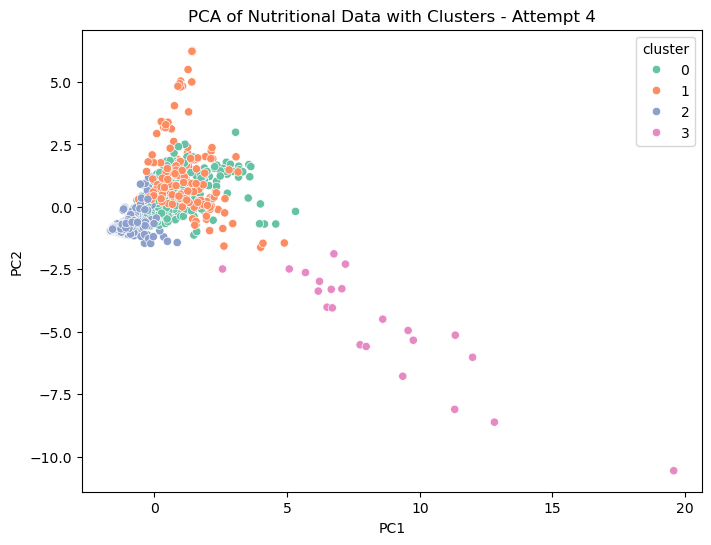

In [53]:
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_4_pca = pca.fit_transform(X_min_scaled_4)

# Step 2: Create a DataFrame for plotting
df_min_4_pca = pd.DataFrame(X_min_4_pca, columns=["PC1", "PC2"])
df_min_4_pca["cluster"] = kmeans_min_4.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_4_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA of Nutritional Data with Clusters - Attempt 4")
plt.show()


### Use silhouette score to determine the optimal number of clusters to have

In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Silhouette scores for Attempt 4, using 'min_nutrients_list_intl")
scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = kmeans.fit_predict(X_min_scaled_4)
    score = silhouette_score(X_min_scaled_4, labels)
    scores[k] = score
    print(f"k={k}, silhouette score ={score:.4f}")

# Optionally: plot scores to visualize the best k

# Output suggests that using only 2 clusters is optimal, but that's not great for the rest of our work
# run model again with k=3 and then look into using other algorithms or redefining features

Silhouette scores for Attempt 4, using 'min_nutrients_list_intl
k=2, silhouette score =0.7721
k=3, silhouette score =0.3805
k=4, silhouette score =0.3533
k=5, silhouette score =0.3871
k=6, silhouette score =0.3905
k=7, silhouette score =0.4004
k=8, silhouette score =0.4208
k=9, silhouette score =0.4226
k=10, silhouette score =0.3889


### Recreate model using min_nutrients_list_intl

### Attempt 4bis - Create model with minimal nutrients list 2 clusters + Visualize clusters: kMeans

### Apply clustering - Attempt 4bis

In [55]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_min_4bis = kmeans_2.fit(X_min_scaled_4)


In [56]:
# Store cluster labels alongside date
df_cluster_min_4bis = X_min_scaled_4.copy()
df_cluster_min_4bis["cluster"] = kmeans_min_4bis.labels_

### Add categorical columns back for interpretation

In [57]:
df_cluster_min_4bis_annotated = df_cluster_min_4bis.merge(
    df_model_min[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')

In [58]:
df_cluster_min_4bis_annotated.groupby("cluster")[min_nutrients_list_intl].mean()

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g)
cluster,,,,,,,,,,
0,0.000515,0.000813,-0.000853,0.001054,0.000637,-0.044925,0.000566,0.000835,0.001689,0.000169
1,-0.182572,-0.288373,0.302561,-0.373818,-0.225869,15.925855,-0.200532,-0.295995,-0.598735,-0.060009


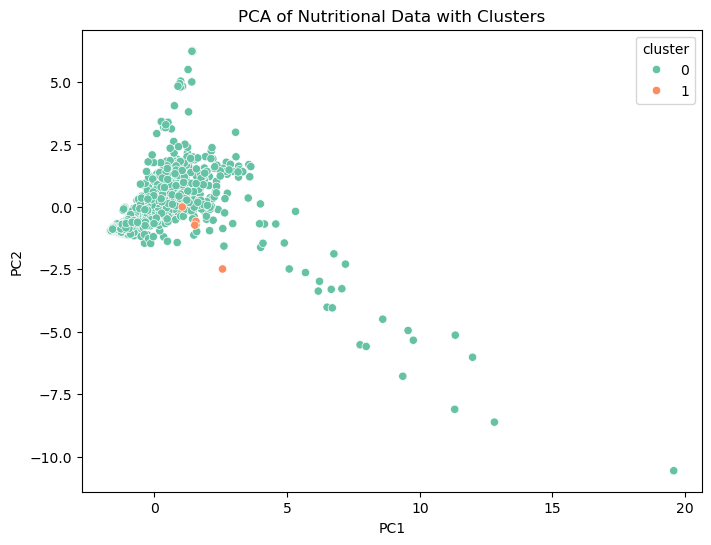

In [59]:
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_4bis_pca = pca.fit_transform(X_min_scaled_4)

# Step 2: Create a DataFrame for plotting
df_min_4bis_pca = pd.DataFrame(X_min_4bis_pca, columns=["PC1", "PC2"])
df_min_4bis_pca["cluster"] = kmeans_min_4bis.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_4bis_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA of Nutritional Data with Clusters")
plt.show()

### Observe subgroups in each cluster

In [60]:
# Count of each sub food group per cluster
cluster_subgroup_counts_4bis = df_cluster_min_4bis_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)

cluster_subgroup_counts_4bis

alim_ssgrp_nom_eng,Viennese pastries,alcoholic beverages,baby biscuits and cereals,baby deserts,baby dishes,baby milk and beverages,breads and similar,breakfast cereals,butters,cakes and pastry,...,savoury pastries and other starters,"seafood, cooked","seafood, raw",seaweed,soups,spices,sweet biscuits,vegetable oils,vegetables,water
cluster,,,,,,,,,,,,,,,,,,,,,
0,18,16,4,3,11,7,33,30,9,6,...,18,11,17,14,20,4,3,17,111,61
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Attempt 4ter: use feature engineering to improve model performance

### Feature engineering: remove foods in unrelated subgroups

In [61]:
# Subgroups to keep
keep_subgroups = [
    'fish, raw', 'fish, cooked', 'seafood, raw', 'seafood, cooked',
    'seaweed', 'vegetables', 'herbs', 'legumes', 'fruits',
    'nuts and seeds', 'milk', 'meat substitute',
    'pasta, rice and grains', 'eggs', 'cooked meat', 'raw meat', 'delicatessen meat', 'other meat products' 
]

# Filter
df_model_min_filtered = df_model_min[
    df_model_min["alim_ssgrp_nom_eng"].isin(keep_subgroups)
].copy()

### Now standardize data again & check optimal number of clusters again before proceeding

In [62]:
df_model_min_filtered

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),...,Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)",approx_count,Omega-3 EPA & DHA,nan_count
338,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",13004,"Avocado, pulp, raw",205.0,20.600,...,0.0000,2.23,0.43,15.0,0.375,0.0075,0.0075,5,0.015,0
339,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20004,"Swiss chard, raw",16.4,0.375,...,0.1875,0.25,0.07,15.0,0.000,0.0075,0.0075,6,0.015,0
340,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20009,"Carrot, raw",40.2,0.375,...,0.0000,0.27,0.18,15.0,0.000,0.0075,0.0075,5,0.015,0
341,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20010,"Mushroom, all types, raw",21.7,0.230,...,0.2000,0.01,0.65,1.0,0.000,0.0000,0.0000,0,0.000,0
343,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20014,"Red cabbage, raw",30.0,0.375,...,0.0000,0.06,0.15,15.0,0.000,0.0075,0.0075,6,0.015,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3110,10,1007,0,miscellaneous,seaweed,-,20994,Toothed wrack or bladder wrack (Fucus serratus...,194.0,1.330,...,NaN,12.20,8.19,40000.0,NaN,NaN,NaN,0,0.000,8
3111,10,1007,0,miscellaneous,seaweed,-,20995,"Sea lettuce (Enteromorpha sp.), dried or dehyd...",224.0,2.470,...,0.0000,11.00,6.08,9390.0,NaN,NaN,NaN,0,0.000,4
3112,10,1007,0,miscellaneous,seaweed,-,20996,"Carragheen mosses (Chondrus crispus), dried or...",234.0,2.300,...,0.0000,NaN,7.86,34600.0,NaN,NaN,NaN,0,0.000,6
3113,10,1007,0,miscellaneous,seaweed,-,20998,"North Atlantic rockweed (Ascophyllum nodosum),...",211.0,2.780,...,0.8900,14.00,6.45,68200.0,NaN,NaN,NaN,0,0.000,5


In [63]:
X_min_4ter = df_model_min_filtered[min_nutrients_list_intl]
X_min_4ter

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g)
338,205.0,20.600,0.83,3.60,1.56,0.015,0.34,9.40,0.43,15.0
339,16.4,0.375,1.63,1.80,1.00,0.570,0.85,25.00,0.07,15.0
340,40.2,0.375,7.59,2.70,0.63,0.110,0.24,25.00,0.18,15.0
341,21.7,0.230,1.88,1.72,2.37,0.012,0.69,7.78,0.65,1.0
343,30.0,0.375,4.33,2.80,1.13,0.035,0.25,36.00,0.15,15.0
...,...,...,...,...,...,...,...,...,...,...
3110,194.0,1.330,15.70,44.60,7.41,10.100,14.70,1170.00,8.19,40000.0
3111,224.0,2.470,18.80,36.00,13.70,11.900,234.00,1610.00,6.08,9390.0
3112,234.0,2.300,21.50,30.60,16.60,5.170,21.10,362.00,7.86,34600.0
3113,211.0,2.780,18.50,41.80,7.22,7.150,21.80,1650.00,6.45,68200.0


In [64]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_min_scaled_4ter = scaler.fit_transform(X_min_4ter)


# turn out from scaling back into a df
X_min_scaled_4ter = pd.DataFrame(X_min_scaled_4, index=X_min_4ter.index, columns=X_min_4ter.columns)

In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Silhouette scores for Attempt 4, using 'min_nutrients_list_intl & reduced subgroups")
scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = kmeans.fit_predict(X_min_scaled_4ter)
    score = silhouette_score(X_min_scaled_4ter, labels)
    scores[k] = score
    print(f"k={k}, silhouette score ={score:.4f}")

    # Results still show that 2 is still the optimal number of clusters, but I'll try with 2 and 3 clusters to see results

Silhouette scores for Attempt 4, using 'min_nutrients_list_intl & reduced subgroups
k=2, silhouette score =0.8180
k=3, silhouette score =0.8034
k=4, silhouette score =0.4357
k=5, silhouette score =0.4391
k=6, silhouette score =0.4523
k=7, silhouette score =0.4888
k=8, silhouette score =0.4777
k=9, silhouette score =0.4781
k=10, silhouette score =0.4768


### Attempt 4ter - 2 (with 2 clusters): Apply clustering and Add categorical columns back for interpretation

In [66]:
kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_min_4ter_2 = kmeans_2.fit(X_min_scaled_4ter)

# Store cluster labels alongside date
df_cluster_min_4ter_2 = X_min_scaled_4ter.copy()
df_cluster_min_4ter_2["cluster"] = kmeans_min_4ter_2.labels_

In [67]:
df_cluster_min_4ter_2_annotated = df_cluster_min_4ter_2.merge(
    df_model_min_filtered[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')

df_cluster_min_4ter_2_annotated.groupby("cluster")[min_nutrients_list_intl].mean()

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g)
cluster,,,,,,,,,,
0,-0.404210,-0.338625,-0.295620,-0.125994,0.291948,-0.166559,-0.065908,-0.225831,0.118301,-0.058152
1,0.182788,-0.479890,0.183833,6.776284,0.464470,1.596293,5.964090,4.357863,1.985557,5.539463


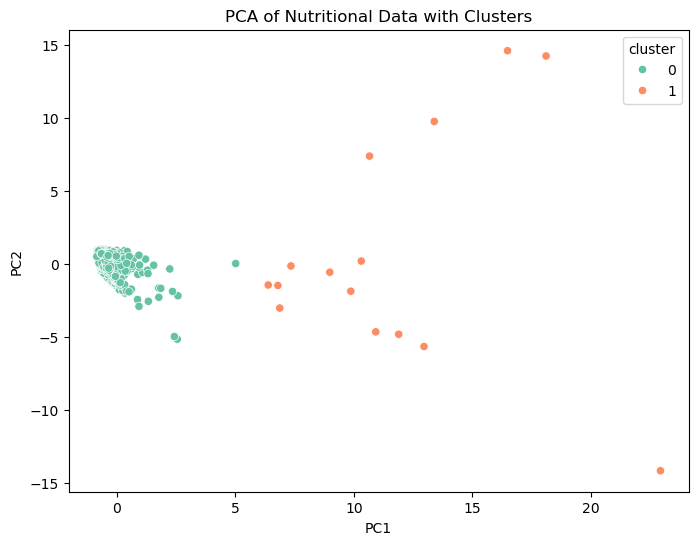

In [68]:
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_4ter_2_pca = pca.fit_transform(X_min_scaled_4ter)

# Step 2: Create a DataFrame for plotting
df_min_4ter_2_pca = pd.DataFrame(X_min_4ter_2_pca, columns=["PC1", "PC2"])
df_min_4ter_2_pca["cluster"] = kmeans_min_4ter_2.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_4ter_2_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA of Nutritional Data with Clusters")
plt.show()

In [69]:
# Count of each sub food group per cluster
cluster_subgroup_counts_4ter_2 = df_cluster_min_4ter_2_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)

cluster_subgroup_counts_4ter_2

alim_ssgrp_nom_eng,cooked meat,eggs,"fish, cooked","fish, raw",fruits,herbs,legumes,meat substitute,milk,nuts and seeds,other meat products,"pasta, rice and grains",raw meat,"seafood, cooked","seafood, raw",seaweed,vegetables
cluster,,,,,,,,,,,,,,,,,
0,57,14,44,74,57,8,7,5,18,4,13,41,81,11,17,1,111
1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,13,0


In [70]:
# Count of each sub food group per cluster
cluster_subgroup_counts_4ter_2 = df_cluster_min_4ter_2_annotated.groupby(["cluster", "alim_ssssgrp_nom_eng"]).size().unstack(fill_value=0)

cluster_subgroup_counts_4ter_2

alim_ssssgrp_nom_eng,-,beef and veal,dried fruits,dried herbs,"eggs, cooked","eggs, raw",fresh fruits,fresh herbs,fruits from Reunion Island and their products,game,...,other meats,"pasta, rice and grains, cooked","pasta, rice and grains, raw",pork,poultry,puréed fruits,turkey,vegetables from Reunion Island and their products,"vegetables, cooked","vegetables, raw"
cluster,,,,,,,,,,,,,,,,,,,,,
0,172,28,5,0,6,3,44,8,3,6,...,17,21,20,14,18,5,4,2,72,37
1,13,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [71]:
df_cluster_min_4ter_2_annotated[df_cluster_min_4ter_2_annotated['alim_ssgrp_nom_eng'].str.contains("seaweed", case=False, na=False)]

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g),cluster,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng
3101,-0.049871,-0.470201,-0.382592,7.630318,0.437561,3.417926,1.913207,4.147744,0.541888,0.825961,1,10,1007,0,miscellaneous,seaweed,-,20984,"Wakame (Undaria pinnatifida), dried or dehydrated"
3102,0.084356,-0.499887,0.008924,6.271628,0.638263,1.149708,9.637083,5.059982,1.549968,0.366063,1,10,1007,0,miscellaneous,seaweed,-,20985,"Sea lettuce (ulva sp.), dried or dehydrated)"
3103,0.072153,-0.559259,0.482610,5.281726,0.013858,2.330775,2.651795,3.240068,0.709901,15.764526,1,10,1007,0,miscellaneous,seaweed,-,20986,"Sea belt (Saccharina latissima), dried or dehy..."
3104,0.383315,-0.524625,-0.150583,6.640415,2.377677,1.158245,4.416894,1.037013,2.091344,0.176257,1,10,1007,0,miscellaneous,seaweed,-,20987,"Laver (Porphyra sp.), dried or dehydrated"
3105,0.212481,-0.543179,0.434274,5.029398,0.783214,0.927724,4.116452,2.081525,1.873549,1.447821,1,10,1007,0,miscellaneous,seaweed,-,20988,"Dulse (Palmaria palmata), dried or dehydrated"
3106,0.194177,-0.461542,0.511611,6.349268,-0.200224,1.570907,1.424988,3.249190,0.037848,10.891742,1,10,1007,0,miscellaneous,seaweed,-,20990,"Kombu or Japanese kelp (Laminaria japonica), d..."
3107,0.151469,-0.555548,0.579280,6.038710,-0.074228,1.986415,0.922998,3.449882,2.321584,22.493609,1,10,1007,0,miscellaneous,seaweed,-,20991,"Tangle (Laminaria digitata), dried or dehydrated"
3108,0.285696,-0.462779,0.709785,5.611694,-0.008442,2.370618,0.076752,2.834122,2.110012,0.607846,0,10,1007,0,miscellaneous,seaweed,-,20992,"Sea thong (Himanthalia elongata), dried or deh..."
3109,0.310100,-0.406499,0.250600,6.388087,0.705163,1.966494,2.226168,5.470489,1.350841,22.864869,1,10,1007,0,miscellaneous,seaweed,-,20993,"Gracilaria seaweeds (Gracilaria verrucosa), dr..."
3110,0.011141,-0.543179,0.100761,8.251433,-0.308380,2.621061,1.600246,4.923147,4.375079,1.795877,1,10,1007,0,miscellaneous,seaweed,-,20994,Toothed wrack or bladder wrack (Fucus serratus...


In [72]:
df_min_4ter_2_pca.head()

,PC1,PC2,cluster
0,-0.391553,0.610793,0
1,-0.621190,0.882549,0
2,-0.549241,0.922626,0
3,-0.603605,0.691595,0
4,-0.539918,0.903849,0


In [73]:
df_cluster_min_4ter_2_annotated.head()

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g),cluster,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng
338,0.078254,0.648596,-0.617985,0.293396,-0.960660,-0.249075,-0.197402,-0.370570,-0.453746,-0.059725,0,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",13004,"Avocado, pulp, raw"
339,-1.072434,-0.602242,-0.579317,-0.055982,-1.023100,-0.091125,-0.133558,-0.299416,-0.677764,-0.059725,0,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20004,"Swiss chard, raw"
340,-0.927225,-0.602242,-0.291238,0.118707,-1.064356,-0.222038,-0.209921,-0.299416,-0.609314,-0.059725,0,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20009,"Carrot, raw"
341,-1.040098,-0.611210,-0.567233,-0.071510,-0.870344,-0.249928,-0.153588,-0.377959,-0.316846,-0.060375,0,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20010,"Mushroom, all types, raw"
343,-0.989458,-0.602242,-0.448811,0.138117,-1.008605,-0.243383,-0.208669,-0.249243,-0.627982,-0.059725,0,2,201,20101,"fruits, vegetables, legumes and nuts",vegetables,"vegetables, raw",20014,"Red cabbage, raw"


### Attempt 3: Define features as nutritional values list with categorical columns


In [74]:
X_min_filtered = df_model_min_filtered[min_nutrients_list_intl]


### Standardize Features

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_min_filtered_scaled = scaler.fit_transform(X_min_filtered)

# turn out from scaling back into a df
X_min_filtered_scaled = pd.DataFrame(X_min_filtered_scaled, index=X_min_filtered.index, columns=X_min_filtered.columns)

### Apply clustering: kMeans

In [76]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_min_filtered = kmeans.fit(X_min_filtered_scaled)


# Store cluster labels alongside date
df_cluster_filtered_min = X_min_filtered_scaled.copy()
df_cluster_filtered_min["cluster"] = kmeans_min_filtered.labels_

### Add categorical columns back for interpretation


In [77]:
df_cluster_filtered_min_annotated = df_cluster_filtered_min.merge(
    df_model_min_filtered[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')


In [78]:
df_cluster_filtered_min_annotated.groupby("cluster")[min_nutrients_list_intl].mean()


,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),Carbohydrate (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Zinc (mg/100g),Iodine (µg/100g)
cluster,,,,,,,,,,
0,2.565782,0.654942,3.362261,0.455986,-0.169327,-0.188250,-0.050068,0.362350,0.226238,-0.093618
1,0.211209,0.357140,-0.455285,-0.355286,0.781261,-0.025258,-0.059619,-0.173601,0.305307,-0.093403
2,-0.765218,-0.577268,0.068058,0.031985,-1.076889,-0.259380,-0.176675,-0.149162,-0.571095,-0.093909
3,1.003699,-0.329255,0.683638,5.430504,0.127767,4.452725,3.683334,4.622805,1.494650,3.288192


### Attempt 3: Visualize clusters


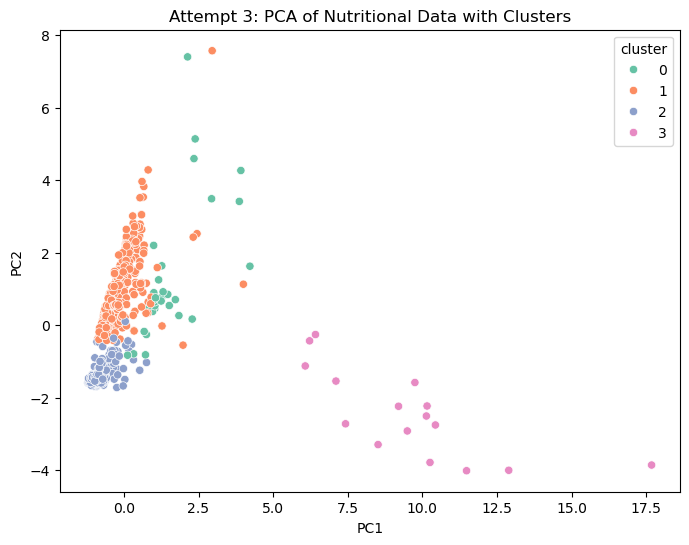

In [79]:
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_filtered_pca = pca.fit_transform(X_min_filtered_scaled)

# Step 2: Create a DataFrame for plotting
df_min_filtered_pca = pd.DataFrame(X_min_filtered_pca, columns=["PC1", "PC2"])
df_min_filtered_pca["cluster"] = kmeans_min_filtered.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_filtered_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("Attempt 3: PCA of Nutritional Data with Clusters")
plt.show()

### Use silhouette score to determine the optimal number of clusters to have

In [80]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = kmeans.fit_predict(X_min_filtered_scaled)
    score = silhouette_score(X_min_filtered_scaled, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.7584
k=3, silhouette score=0.3775
k=4, silhouette score=0.4216
k=5, silhouette score=0.4260
k=6, silhouette score=0.4286
k=7, silhouette score=0.4300
k=8, silhouette score=0.4399
k=9, silhouette score=0.4289
k=10, silhouette score=0.4295


In [81]:



# Optionally: plot scores to visualize the best k

# Output suggests that using only 2 clusters is optimal, but that's not great for the rest of our work
# run model again with k=3 and then look into using other algorithms or redefining features
# 1. Run KMeans with k=2
kmeans_min_2 = KMeans(n_clusters=2, random_state=42, n_init=15)
labels_min_2 = kmeans_min_2.fit_predict(X_min_filtered_scaled)

# 2. Create a DataFrame with the cluster labels
df_cluster_min_2 = pd.DataFrame(index=X_min_filtered_scaled.index)
df_cluster_min_2["cluster"] = labels_min_2

# 3. Annotate with metadata (subgroup names, etc.)
df_cluster_min_2_annotated = df_cluster_min_2.join(
    df_nutri_intl_filtered_no_nan[["alim_ssgrp_nom_eng", "alim_nom_eng"]]
)




## Interpretation

## View cluster distribution by Subgroup

# Count of each sub food group per cluster
cluster_subgroup_counts = df_cluster_min_2_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)
cluster_subgroup_counts


alim_ssgrp_nom_eng,cooked meat,eggs,"fish, cooked","fish, raw",fruits,herbs,legumes,meat substitute,milk,nuts and seeds,other meat products,"pasta, rice and grains",raw meat,"seafood, cooked","seafood, raw",seaweed,vegetables
cluster,,,,,,,,,,,,,,,,,
0,57,14,44,74,57,8,7,5,18,4,13,41,81,11,17,0,111
1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,14,0


## Interpretation

### View cluster distribution by Subgroup

In [82]:
# Count of each sub food group per cluster
cluster_subgroup_counts = df_cluster_min_2_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)
cluster_subgroup_counts


alim_ssgrp_nom_eng,cooked meat,eggs,"fish, cooked","fish, raw",fruits,herbs,legumes,meat substitute,milk,nuts and seeds,other meat products,"pasta, rice and grains",raw meat,"seafood, cooked","seafood, raw",seaweed,vegetables
cluster,,,,,,,,,,,,,,,,,
0,57,14,44,74,57,8,7,5,18,4,13,41,81,11,17,0,111
1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,14,0


In [83]:
df_cluster_min_2_annotated[
    df_cluster_min_2_annotated['alim_ssgrp_nom_eng'].str.contains('seaweed', case=False, na=False)
]['alim_ssgrp_nom_eng'].value_counts()


alim_ssgrp_nom_eng
seaweed    14
Name: count, dtype: int64

In [84]:
sorted(df_cluster_min_2_annotated["alim_ssgrp_nom_eng"].dropna().unique())

['cooked meat',
 'eggs',
 'fish, cooked',
 'fish, raw',
 'fruits',
 'herbs',
 'legumes',
 'meat substitute',
 'milk',
 'nuts and seeds',
 'other meat products',
 'pasta, rice and grains',
 'raw meat',
 'seafood, cooked',
 'seafood, raw',
 'seaweed',
 'vegetables']

In [85]:
df_cluster_min_2_annotated["alim_ssgrp_nom_eng"].nunique()


17

### Plot of Subgroup Color/Label

In [86]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. Run KMeans with k=2 on the SAME dataset used for PCA
kmeans_min_2 = KMeans(n_clusters=2, random_state=42, n_init=15)
labels_min_2 = kmeans_min_2.fit_predict(X_min_filtered_scaled)

# 2. Run PCA on the SAME dataset
pca = PCA(n_components=2)
X_min_2_pca = pca.fit_transform(X_min_filtered_scaled)

# 3. Build the PCA DataFrame
df_min_2_pca = pd.DataFrame(
    X_min_2_pca,
    index=X_min_filtered_scaled.index,
    columns=["PC1", "PC2"]
)

# 4. Add cluster labels
df_min_2_pca["cluster"] = labels_min_2


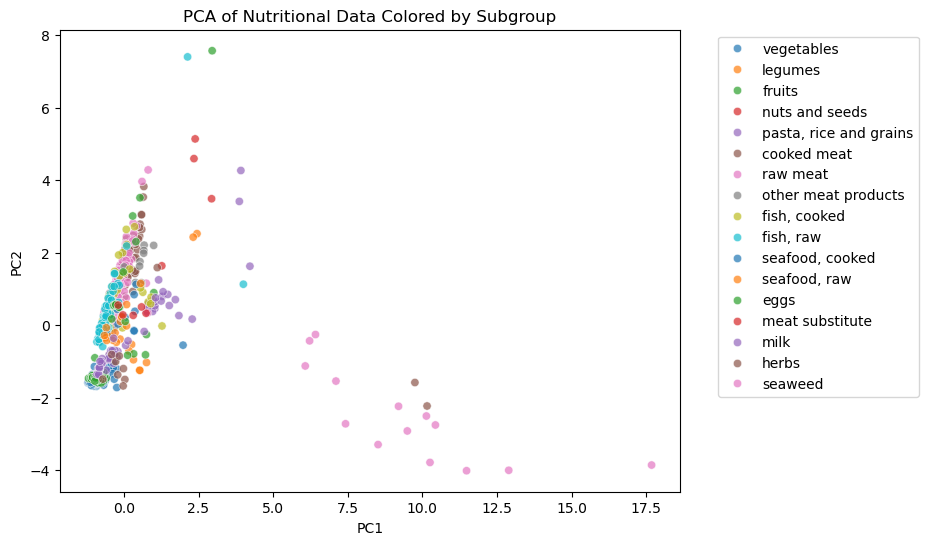

In [87]:
# Add food subgroup info to PCA plot
df_min_2_pca["subgroup"] = df_cluster_min_2_annotated["alim_ssgrp_nom_eng"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_2_pca, x="PC1", y="PC2", hue="subgroup", palette="tab10", alpha=0.7)
plt.title("PCA of Nutritional Data Colored by Subgroup")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.show()


In [88]:
# Count of each sub food group per cluster
cluster_subgroup_filtered_counts = df_cluster_filtered_min_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)
cluster_subgroup_filtered_counts

alim_ssgrp_nom_eng,cooked meat,eggs,"fish, cooked","fish, raw",fruits,herbs,legumes,meat substitute,milk,nuts and seeds,other meat products,"pasta, rice and grains",raw meat,"seafood, cooked","seafood, raw",seaweed,vegetables
cluster,,,,,,,,,,,,,,,,,
0,0,0,0,1,5,0,0,0,4,4,1,19,0,0,0,0,0
1,57,12,44,69,0,0,0,5,0,0,12,0,81,11,16,0,1
2,0,2,0,4,52,8,7,0,14,0,0,22,0,0,1,0,110
3,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,14,0


### Attempt 3:  Plot of Subgroup Color/Label

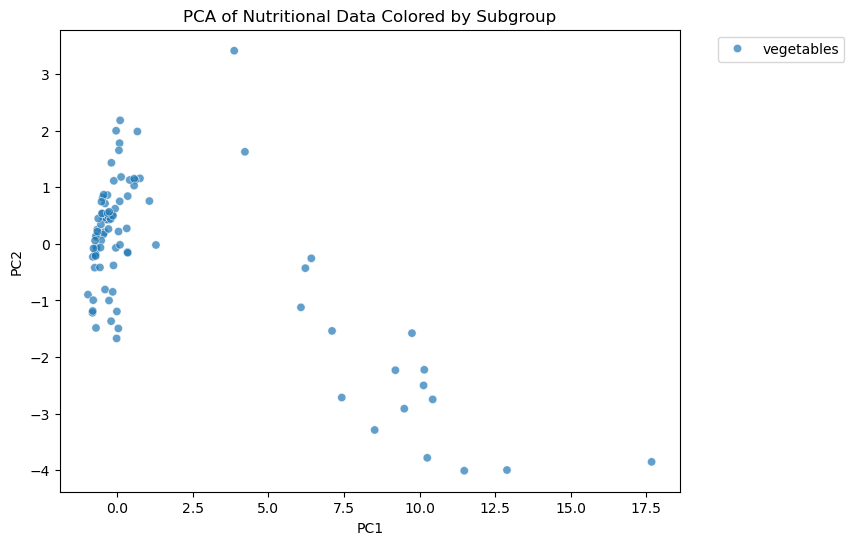

In [89]:
# Add food subgroup info to PCA plot
df_min_filtered_pca["subgroup"] = df_cluster_filtered_min_annotated["alim_ssgrp_nom_eng"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_filtered_pca, x="PC1", y="PC2", hue="subgroup", palette="tab10", alpha=0.7)
plt.title("PCA of Nutritional Data Colored by Subgroup")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.show()

from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_filtered_pca = pca.fit_transform(X_min_filtered_scaled)

# Step 2: Create a DataFrame for plotting
df_min_filtered_pca = pd.DataFrame(X_min_filtered_pca, columns=["PC1", "PC2"])
df_min_filtered_pca["cluster"] = kmeans_min_filtered.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_filtered_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("Attempt 3: PCA of Nutritional Data with Clusters")
plt.show()

In [90]:
# drop NaNs, to prepare for fitting and training model
df_model = df_cleaned.dropna(subset=nutrients_list_intl).copy()

df_model.isna().sum()

alim_grp_code                                       0
alim_ssgrp_code                                     0
alim_ssssgrp_code                                   0
alim_grp_nom_eng                                    0
alim_ssgrp_nom_eng                                  0
alim_ssssgrp_nom_eng                                0
alim_code                                           0
alim_nom_eng                                        0
Energy, Regulation EU No 1169/2011 (kcal/100g)      0
Fat (g/100g)                                        0
FA saturated (g/100g)                               0
Carbohydrate (g/100g)                               0
Sugars (g/100g)                                     0
Fibres (g/100g)                                     0
Protein (g/100g)                                    0
Salt (g/100g)                                       0
Iron (mg/100g)                                      0
Calcium (mg/100g)                                   0
Magnesium (mg/100g)         

# TEMPLATE alg

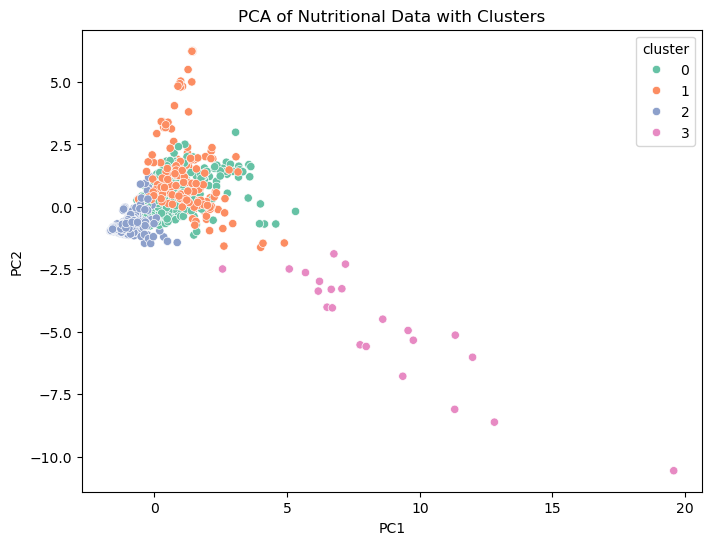

k=2, silhouette score=0.7721
k=3, silhouette score=0.3805
k=4, silhouette score=0.3533
k=5, silhouette score=0.3871
k=6, silhouette score=0.3905
k=7, silhouette score=0.4004
k=8, silhouette score=0.4208
k=9, silhouette score=0.4226
k=10, silhouette score=0.3889


alim_ssgrp_nom_eng,cooked meat,eggs,"fish, cooked","fish, raw",fruits,herbs,legumes,meat substitute,milk,nuts and seeds,other meat products,"pasta, rice and grains",raw meat,"seafood, cooked","seafood, raw",seaweed,vegetables
cluster,,,,,,,,,,,,,,,,,
0,57,14,44,74,57,8,7,5,18,4,13,41,81,11,17,0,111
1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,14,0


In [91]:
### Define features as nutritional values list with categorical columns
X_min = df_model_min[min_nutrients_list_intl]



### Standardize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_min_scaled = scaler.fit_transform(X_min)


# turn out from scaling back into a df
X_min_scaled = pd.DataFrame(X_min_scaled, index=X_min.index, columns=X_min.columns)



### Apply clustering: kMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_min = kmeans.fit(X_min_scaled)


# Store cluster labels alongside date
df_cluster_min = X_min_scaled.copy()
df_cluster_min["cluster"] = kmeans_min.labels_




### Add categorical columns back for interpretation
df_cluster_min_annotated = df_cluster_min.merge(
    df_model_min[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')



df_cluster_min_annotated.groupby("cluster")[min_nutrients_list_intl].mean()




### Attempt 1: Visualize clusters
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_min_pca = pca.fit_transform(X_min_scaled)

# Step 2: Create a DataFrame for plotting
df_min_pca = pd.DataFrame(X_min_pca, columns=["PC1", "PC2"])
df_min_pca["cluster"] = kmeans_min.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_min_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA of Nutritional Data with Clusters")
plt.show()



### Use silhouette score to determine the optimal number of clusters to have

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = kmeans.fit_predict(X_min_scaled)
    score = silhouette_score(X_min_scaled, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

# Optionally: plot scores to visualize the best k

# Output suggests that using only 2 clusters is optimal, but that's not great for the rest of our work
# run model again with k=3 and then look into using other algorithms or redefining features



## Interpretation

### View cluster distribution by Subgroup

# Count of each sub food group per cluster
cluster_subgroup_counts = df_cluster_min_2_annotated.groupby(["cluster", "alim_ssgrp_nom_eng"]).size().unstack(fill_value=0)
cluster_subgroup_counts


### OLD Define features as nutritional values list with categorical columns

In [92]:
X = df_model[nutrients_list_intl]


### Define features as nutritional values list with categorical columns

### Standardize Features

In [93]:

X = df_model[nutrients_list_intl]


### Define features as nutritional values list with categorical columns

### Standardize Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# turn out from scaling back into a df
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)



### Apply clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Store cluster labels alongside date
df_cluster = X_scaled.copy()
df_cluster["cluster"] = kmeans.labels_


### add categorical columns back for interpretation
df_cluster_annotated = df_cluster.merge(
    df_cleaned[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')





df_cluster_annotated.groupby("cluster")[nutrients_list_intl].mean()



,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),FA saturated (g/100g),Carbohydrate (g/100g),Sugars (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.074657,0.012496,0.073529,-0.597898,-0.476481,-0.411899,1.058409,0.025951,0.097401,0.097648,...,-0.152691,0.415515,0.109815,0.063699,-0.159599,0.522653,0.382972,0.457175,0.182884,0.198666
1,1.091598,0.007171,0.079192,2.331745,1.951536,1.528055,-0.198554,-0.099887,1.247755,0.606834,...,0.338395,-0.208660,0.282863,-0.075053,0.331542,0.270916,-0.244601,-0.326689,-0.174124,-0.181904
2,-0.450747,-0.353965,-0.314879,0.036343,0.007437,0.041564,-0.706593,0.010598,-0.303380,-0.175185,...,0.078756,-0.262812,-0.120147,-0.108130,-0.184473,-0.422870,-0.246663,-0.311617,-0.159699,-0.169883
3,3.492093,4.257407,2.982251,-0.637319,-0.483630,-0.440286,-1.133288,-0.127099,-0.442583,-0.367334,...,-0.355966,-0.285408,-0.326668,0.911674,3.001546,-0.602515,-0.071637,0.218241,0.636084,0.627370


In [94]:
# turn out from scaling back into a df
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

### Apply clustering

In [95]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# Store cluster labels alongside date
df_cluster = X_scaled.copy()
df_cluster["cluster"] = kmeans.labels_


### add categorical columns back for interpretation

In [96]:
df_cluster_annotated = df_cluster.merge(
    df_cleaned[[
               'alim_grp_code', 'alim_ssgrp_code', 'alim_ssssgrp_code',
                'alim_grp_nom_eng', 'alim_ssgrp_nom_eng', 'alim_ssssgrp_nom_eng',
                'alim_code', 'alim_nom_eng'
                ]],
    left_index=True,
    right_index=True,
    how='left')

In [97]:
df_cluster_annotated.groupby("cluster")[nutrients_list_intl].mean()

,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),FA saturated (g/100g),Carbohydrate (g/100g),Sugars (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),...,Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.074657,0.012496,0.073529,-0.597898,-0.476481,-0.411899,1.058409,0.025951,0.097401,0.097648,...,-0.152691,0.415515,0.109815,0.063699,-0.159599,0.522653,0.382972,0.457175,0.182884,0.198666
1,1.091598,0.007171,0.079192,2.331745,1.951536,1.528055,-0.198554,-0.099887,1.247755,0.606834,...,0.338395,-0.208660,0.282863,-0.075053,0.331542,0.270916,-0.244601,-0.326689,-0.174124,-0.181904
2,-0.450747,-0.353965,-0.314879,0.036343,0.007437,0.041564,-0.706593,0.010598,-0.303380,-0.175185,...,0.078756,-0.262812,-0.120147,-0.108130,-0.184473,-0.422870,-0.246663,-0.311617,-0.159699,-0.169883
3,3.492093,4.257407,2.982251,-0.637319,-0.483630,-0.440286,-1.133288,-0.127099,-0.442583,-0.367334,...,-0.355966,-0.285408,-0.326668,0.911674,3.001546,-0.602515,-0.071637,0.218241,0.636084,0.627370


### Visualize clusters

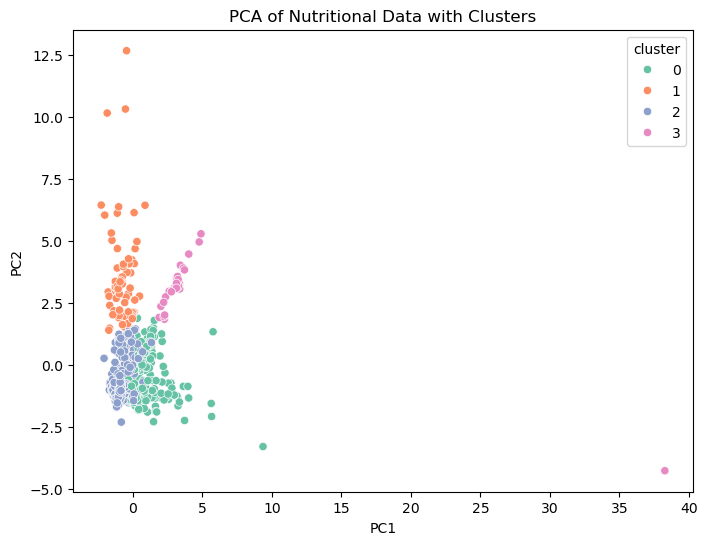

In [98]:
from sklearn.decomposition import PCA

# Step 1: Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 2: Create a DataFrame for plotting
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = kmeans.labels_

# Step 3: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA of Nutritional Data with Clusters")
plt.show()


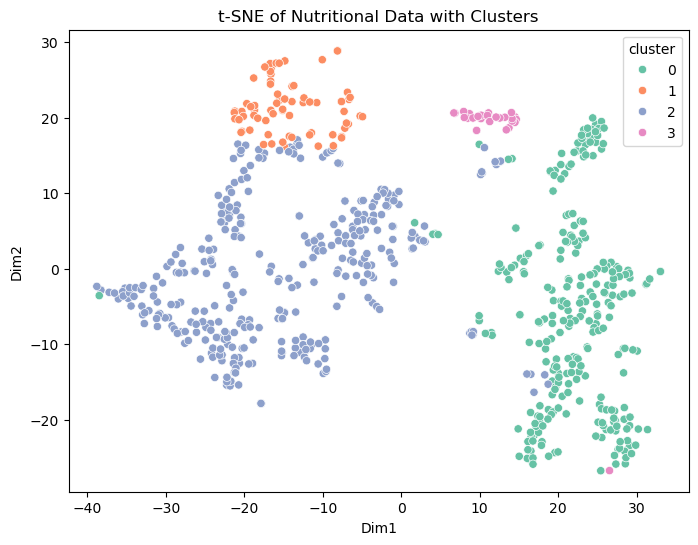

In [99]:
from sklearn.manifold import TSNE

# Step 1: Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Step 2: Plot
df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
df_tsne["cluster"] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_tsne, x="Dim1", y="Dim2", hue="cluster", palette="Set2")
plt.title("t-SNE of Nutritional Data with Clusters")
plt.show()


In [100]:
print(nutrients_list_intl)
print(df_cleaned[nutrients_list_intl].dtypes)

['Energy, Regulation EU No 1169/2011 (kcal/100g)', 'Fat (g/100g)', 'FA saturated (g/100g)', 'Carbohydrate (g/100g)', 'Sugars (g/100g)', 'Fibres (g/100g)', 'Protein (g/100g)', 'Salt (g/100g)', 'Iron (mg/100g)', 'Calcium (mg/100g)', 'Magnesium (mg/100g)', 'Vitamin C (mg/100g)', 'Vitamin B12 (µg/100g)', 'Vitamin B9 or Folate (µg/100g)', 'Vitamin D (µg/100g)', 'Vitamin E (mg/100g)', 'Zinc (mg/100g)', 'Iodine (µg/100g)', 'Cholesterol (mg/100g)', 'FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)', 'FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)']
Energy, Regulation EU No 1169/2011 (kcal/100g)      float64
Fat (g/100g)                                        float64
FA saturated (g/100g)                               float64
Carbohydrate (g/100g)                               float64
Sugars (g/100g)                                     float64
Fibres (g/100g)                                     float64
Protein (g/100g)                                    float64
Salt (g/100g)                      

In [101]:
print(X_scaled[nutrients_list_intl].dtypes)
print(X_scaled[:5])

Energy, Regulation EU No 1169/2011 (kcal/100g)      float64
Fat (g/100g)                                        float64
FA saturated (g/100g)                               float64
Carbohydrate (g/100g)                               float64
Sugars (g/100g)                                     float64
Fibres (g/100g)                                     float64
Protein (g/100g)                                    float64
Salt (g/100g)                                       float64
Iron (mg/100g)                                      float64
Calcium (mg/100g)                                   float64
Magnesium (mg/100g)                                 float64
Vitamin C (mg/100g)                                 float64
Vitamin B12 (µg/100g)                               float64
Vitamin B9 or Folate (µg/100g)                      float64
Vitamin D (µg/100g)                                 float64
Vitamin E (mg/100g)                                 float64
Zinc (mg/100g)                          

In [102]:
# 1. Join cluster labels to original cleaned dataframe
# Only add cluster labels to the same rows used in clustering (i.e., X)
df_clustered = df_cleaned.loc[X.index].copy()
df_clustered["cluster"] = kmeans.labels_

# 2. Filter only seaweed rows (you might need to adjust this name)
seaweed_rows = df_clustered[df_clustered["alim_ssgrp_nom_eng"].str.contains("water", case=False, na=False)]

# 3. Check which cluster(s) seaweed appears in
print(seaweed_rows[["alim_ssgrp_nom_eng", "cluster"]])

# 4. See other foods in same cluster(s)
seaweed_clusters = seaweed_rows["cluster"].unique()
similar_foods = df_clustered[df_clustered["cluster"].isin(seaweed_clusters)]

# Optional: show top N similar foods
print(similar_foods[["alim_ssgrp_nom_eng", "cluster"]].sort_values("cluster"))


Empty DataFrame
Columns: [alim_ssgrp_nom_eng, cluster]
Index: []
Empty DataFrame
Columns: [alim_ssgrp_nom_eng, cluster]
Index: []


In [103]:
df_clustered["alim_ssgrp_nom_eng"].value_counts()

alim_ssgrp_nom_eng
vegetables                             48
raw meat                               46
dishes                                 46
fish, raw                              43
dairy products and similar             42
cheese and similar                     39
non-alcoholic beverages                33
fruits                                 33
cooked meat                            33
delicatessen meat and similar          30
fish, cooked                           29
fish products                          24
pasta, rice and grains                 22
vegetable oils                         14
seafood, raw                           14
breakfast cereals                      14
potatoes and other tubers              14
pizzas, crepe and pies                 14
milk                                   13
savoury pastries and other starters    13
baby dishes                            11
Viennese pastries                      10
eggs                                    9
butters        

In [104]:
# removing specific rows (with missing NAN values) by using their indices

rows_to_remove = [3, 7, 12]  # example list of indices
df_filtered = df_nutri_intl.drop(index=rows_to_remove)



In [105]:
# Sub groups of food to compare with seaweed

sub_groups = ["seaweed", "cooked meat", "fish, raw", "fish, cooked", "nuts and seeds", "eggs", "seafood, cooked"]


In [106]:
df_nutri_intl_filtered = df_nutri_intl[df_nutri_intl["alim_ssgrp_nom_eng"].isin(sub_groups)]

df_nutri_intl_filtered_nans = df_nutri_intl_filtered[df_nutri_intl_filtered.isna().any(axis=1)]

df_nutri_intl_filtered_nans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 1142 to 1922
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   alim_grp_code                                     12 non-null     int64 
 1   alim_ssgrp_code                                   12 non-null     int64 
 2   alim_ssssgrp_code                                 12 non-null     int64 
 3   alim_grp_nom_eng                                  12 non-null     object
 4   alim_ssgrp_nom_eng                                12 non-null     object
 5   alim_ssssgrp_nom_eng                              12 non-null     object
 6   alim_code                                         12 non-null     int64 
 7   alim_nom_eng                                      12 non-null     object
 8   Energy, Regulation EU No 1169/2011 (kcal/100g)    12 non-null     object
 9   Fat (g/100g)                      

In [107]:
pd.set_option('display.max_columns', None)

df_nutri_intl_filtered_nans.head(27)


,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_eng,alim_ssgrp_nom_eng,alim_ssssgrp_nom_eng,alim_code,alim_nom_eng,"Energy, Regulation EU No 1169/2011 (kcal/100g)",Fat (g/100g),FA saturated (g/100g),Carbohydrate (g/100g),Sugars (g/100g),Fibres (g/100g),Protein (g/100g),Salt (g/100g),Iron (mg/100g),Calcium (mg/100g),Magnesium (mg/100g),Vitamin C (mg/100g),Vitamin B12 (µg/100g),Vitamin B9 or Folate (µg/100g),Vitamin D (µg/100g),Vitamin E (mg/100g),Zinc (mg/100g),Iodine (µg/100g),Cholesterol (mg/100g),"FA 20:5 5c,8c,11c,14c,17c (n-3) EPA (g/100g)","FA 22:6 4c,7c,10c,13c,16c,19c (n-3) DHA (g/100g)"
1142,4,401,0,"meat, egg and fish",cooked meat,-,6585,"Red meat, cooked (average)",195,"10,1","4,16","0,027",NaN,0,26,"0,22","2,84","11,8","28,3",NaN,"2,31","9,44","0,094","0,25","5,44","6,17","76,7",NaN,"0,0015"
1181,4,401,40101,"meat, egg and fish",cooked meat,beef and veal,6564,"Veal, meat, cooked (average)",169,"5,55","1,79","0,74",NaN,"0,053",29,"0,25","0,95","14,9",27,NaN,"1,92",NaN,NaN,"0,57","4,46",NaN,"87,9",NaN,"0,0015"
1193,4,401,40102,"meat, egg and fish",cooked meat,pork,28205,"Pork, meat, cooked (average)",205,"9,78","3,52","0,24",NaN,0,"29,1","0,12","0,87","10,1","28,5","0,27","0,59","7,15","0,51","0,12","2,38","5,68",78,"0,014","0,0035"
1221,4,401,40105,"meat, egg and fish",cooked meat,lamb and mutton,21522,"Lamb, chop, cooked (avergae)",157,"5,78","2,21",0,NaN,0,"26,3",NaN,"1,27",NaN,NaN,NaN,"1,22",NaN,NaN,"0,16","3,55",NaN,86,NaN,"0,0057"
1222,4,401,40105,"meat, egg and fish",cooked meat,lamb and mutton,21523,"Lamb, meat, cooked (average)",208,"10,6","3,66","0,011",NaN,0,"28,1",NaN,"1,74",NaN,NaN,NaN,"2,27",NaN,NaN,"0,17","4,94",NaN,"92,8",NaN,"0,0058"
1223,4,401,40105,"meat, egg and fish",cooked meat,lamb and mutton,21524,"Lamb, chop, grilled (average)",157,"5,78","2,21",0,NaN,0,"26,3",NaN,"1,27",NaN,NaN,NaN,"1,22",NaN,NaN,"0,16","3,55",NaN,86,NaN,"0,0057"
1227,4,401,40106,"meat, egg and fish",cooked meat,game,14008,"Game, cooked (average)",152,"3,74","1,26",0,NaN,0,"29,6","0,14","3,03","11,8","25,8",0,"1,26","6,18",NaN,NaN,"2,84",NaN,"97,4",NaN,NaN
1229,4,401,40106,"meat, egg and fish",cooked meat,game,36603,"Feathered game, meat, cooked (average)",217,13,"3,24",0,0,0,"25,1","0,73","4,2","6,81","31,3","2,08","2,78","9,46","0,55","0,54","2,12","10,1",109,NaN,NaN
1267,4,401,40108,"meat, egg and fish",cooked meat,offals,40401,"Kidney, all types, cooked",161,"6,31","1,61",0,0,0,"26,1","0,25","7,35","17,1","14,6",NaN,"31,2","70,2","0,44","0,57","3,96",10,440,"0,006","0,004"
1625,4,405,0,"meat, egg and fish","fish, cooked",-,25996,"Salmon, cooked (average)",205,"12,5","2,5",0,0,0,23,"0,13","0,35","11,5","28,6","2,79","2,78","19,9",NaN,NaN,"0,42",NaN,"57,3","0,68","1,38"
